
# Santander Customer Transaction Prediction

**Kaggle Competition · Supervised Machine Learning · Binary Classification**

---

## Objetivo del proyecto

El objetivo de este proyecto es predecir si un cliente del Banco Santander realizará una transacción específica en el futuro.

Se trata de un problema de **clasificación binaria**, donde la variable objetivo indica si el cliente pertenece a la clase positiva (`target = 1`) o a la clase negativa (`target = 0`).

---

## Contexto del dataset

El dataset contiene:

- **200.000 clientes** en el conjunto de entrenamiento.
- **200 variables numéricas anonimizadas** (`var_0` a `var_199`).
- Una variable objetivo: `target`.
- Aproximadamente **un 10% de clase positiva**, lo que implica un problema con desbalance de clases.

Al estar las variables anonimizadas, no es posible interpretar directamente el significado de cada predictor. Por tanto, el análisis se centrará en patrones estadísticos, distribución de variables, relación con el target y capacidad predictiva.

---

## Métrica de evaluación

La competición utiliza como métrica principal:

**ROC-AUC**

Esta métrica es adecuada para problemas de clasificación binaria con clases desbalanceadas, ya que evalúa la capacidad del modelo para ordenar correctamente los casos positivos por encima de los negativos, independientemente de un umbral fijo de clasificación.

---

## Competición original

[Kaggle - Santander Customer Transaction Prediction (2019)](https://www.kaggle.com/c/santander-customer-transaction-prediction)

# Mapa de etapas del proyecto

Este notebook sigue una estructura inspirada en la **Machine Learning Checklist**, combinando dos enfoques:

1. **Enfoque Kaggle:** resolver correctamente la competición y generar una submission válida.
2. **Enfoque profesional simulado:** actuar como Data Scientist dentro de un banco que necesita priorizar clientes con mayor probabilidad de realizar una transacción futura.

El objetivo no es solo obtener un buen score, sino construir un proyecto trazable, defendible y conectado con una posible decisión de negocio.

---

## Mapa de etapas

| Etapa | Descripción | Sección |
|---|---|---|
| 1. Business Understanding | Contexto, objetivo del problema y ML Canvas | S1 y S2 |
| 2. Data Understanding | Descripción del dataset, carga de datos, auditoría técnica y EDA | S3, S4 y S5 |
| 3. Data Preparation | Feature engineering y preprocesado | S6 y S7 |
| 4. Modeling | Baseline, LightGBM y comparación de modelos | S8 |
| 5. Evaluation | Métricas, curvas de evaluación, análisis de umbral e interpretabilidad | S9 |
| 6. Deployment | Submission a Kaggle, conclusiones y siguientes pasos | S10 y S11 |

---

## Índice

1. Introducción y contexto del problema  
2. ML Canvas  
3. Descripción del dataset  
4. Carga y auditoría técnica  
5. EDA profundo  
6. Feature Engineering  
7. Preprocesado y Pipeline  
8. Modelado  
9. Evaluación e interpretabilidad  
10. Submission a Kaggle  
11. Conclusiones y siguientes pasos  

---

## Enfoque de role play profesional

A lo largo del notebook se trabajará bajo el siguiente supuesto:

> El Banco Santander quiere identificar clientes con alta probabilidad de realizar una transacción futura para priorizar acciones comerciales, optimizar recursos y mejorar la toma de decisiones.

Bajo este escenario, el modelo no se evaluará únicamente por su score en Kaggle, sino también por su utilidad potencial para negocio:

- ¿Ordena correctamente a los clientes según probabilidad?
- ¿Qué coste tiene usar un umbral demasiado bajo o demasiado alto?
- ¿Qué implica priorizar recall frente a precision?
- ¿Qué riesgos aparecen al trabajar con variables completamente anonimizadas?
- ¿Qué limitaciones tendría este modelo antes de llevarlo a producción?

Este enfoque permite conectar las decisiones técnicas del proyecto con criterios reales de Data Science aplicado.

# 1. Introducción y contexto del problema

El Banco Santander es una entidad financiera internacional que opera en un entorno donde anticiparse al comportamiento del cliente puede generar una ventaja competitiva relevante. Identificar patrones de comportamiento permite personalizar acciones comerciales, optimizar recursos y mejorar la experiencia del usuario.

En 2019, Santander planteó en Kaggle el siguiente reto: predecir si un cliente realizará una transacción específica en el futuro, independientemente del importe de dicha transacción.

El problema es deliberadamente abstracto. Las variables están completamente anonimizadas para proteger la privacidad de los clientes y los activos de negocio del banco. Como consecuencia, no es posible interpretar directamente qué representa cada variable ni asociarla a conceptos financieros concretos como ingresos, saldo, antigüedad o uso de productos.

Esto convierte el proyecto en un reto principalmente estadístico y predictivo. El valor diferencial no proviene del conocimiento directo del dominio financiero, sino de la capacidad para detectar patrones en un dataset de alta dimensionalidad, con variables numéricas anonimizadas y una clase positiva minoritaria.

A lo largo de este notebook se desarrollan todas las etapas del proceso de Machine Learning: desde la comprensión del problema y el análisis exploratorio hasta el feature engineering, el modelado, la evaluación y la generación de la submission final.

Además del enfoque propio de Kaggle, el proyecto se trabajará como una simulación profesional: actuar como Data Scientist dentro de un banco que necesita priorizar clientes con mayor probabilidad de realizar una transacción futura. Por tanto, las decisiones técnicas se evaluarán no solo por su impacto en la métrica de competición, **ROC-AUC**, sino también por su posible utilidad para negocio y por sus limitaciones antes de llevar un modelo de este tipo a producción.


# 2. ML Canvas

## 2.1 Problema de negocio

El objetivo del proyecto es identificar, entre los clientes de Santander, aquellos con mayor probabilidad de realizar una transacción específica en el futuro.

Bajo un escenario profesional simulado, este conocimiento permitiría al banco actuar de forma proactiva: priorizar campañas comerciales, personalizar la comunicación con el cliente y asignar recursos de manera más eficiente.

El reto no consiste únicamente en predecir una clase, sino en construir un sistema capaz de **ordenar clientes por probabilidad estimada de transacción**, de forma que el equipo de negocio pueda decidir sobre qué clientes actuar primero.

---

## 2.2 Usuario final y stakeholders

El stakeholder principal sería el equipo de analítica avanzada o CRM del Banco Santander, responsable de utilizar las predicciones del modelo dentro de procesos comerciales o de relación con clientes.

El usuario final indirecto sería el cliente, que podría recibir una comunicación más personalizada como consecuencia de las decisiones habilitadas por el modelo.

Dado que las variables están completamente anonimizadas, este proyecto no permite explicar el comportamiento del cliente desde variables de negocio concretas. La utilidad principal del modelo está en su capacidad predictiva y de priorización.

---

## 2.3 Decisión habilitada por el modelo

El modelo estima, para cada cliente, una probabilidad de pertenecer a la clase positiva (`target = 1`).

Cuando esta probabilidad supera un umbral definido por negocio, el cliente podría ser marcado como candidato prioritario para una acción comercial específica, como una oferta, una comunicación personalizada o un seguimiento.

El modelo no ejecuta acciones directamente. Su función es generar un **score de propensión** que alimente los procesos de decisión del equipo comercial.

La elección del umbral no es puramente técnica: depende del coste relativo entre contactar a clientes que no transaccionarán y dejar fuera a clientes que sí habrían transaccionado.

---

## 2.4 Tipo de problema de Machine Learning

Este proyecto corresponde a un problema de **aprendizaje supervisado de clasificación binaria**.

La variable objetivo es conocida en el conjunto de entrenamiento:

- `target = 1`: el cliente realizó la transacción.
- `target = 0`: el cliente no realizó la transacción.

El objetivo del modelo no es solo asignar una clase final, sino estimar una probabilidad para cada cliente. Esto permite trabajar con distintos umbrales de decisión según las necesidades del negocio.

---

## 2.5 Variable objetivo

La variable objetivo es `target`, una variable binaria que indica si el cliente realizó o no la transacción.

El dataset presenta un fuerte desbalance de clases: aproximadamente el 10% de los clientes pertenecen a la clase positiva (`target = 1`).

Este desbalance tiene implicaciones directas:

- La métrica `accuracy` puede ser engañosa.
- Es necesario evaluar la capacidad de discriminación del modelo.
- El umbral de clasificación por defecto (`0.5`) no tiene por qué ser el más adecuado.
- Métricas como ROC-AUC, PR-AUC, precision y recall serán más útiles para entender el rendimiento real del modelo.

---

## 2.6 Variables de entrada

El dataset contiene 200 variables numéricas anonimizadas, desde `var_0` hasta `var_199`.

No se dispone de información sobre:

- significado de las variables,
- unidades de medida,
- origen de los datos,
- relación directa con productos financieros,
- interpretación de negocio individual.

No existen variables categóricas explícitas ni variables temporales directas.

Esta anonimización limita la interpretación semántica del modelo. Por tanto, el análisis se centrará en patrones estadísticos, distribuciones, relaciones con el target y capacidad predictiva.

---

## 2.7 Riesgos y trade-offs del modelo

En un problema de clasificación binaria aplicado a campañas comerciales, los dos errores principales son:

**Falso positivo:**  
El modelo identifica como prioritario a un cliente que finalmente no realizará la transacción.  
Impacto potencial: coste comercial innecesario, pérdida de eficiencia y posible saturación del cliente.

**Falso negativo:**  
El modelo no identifica como prioritario a un cliente que sí realizará la transacción.  
Impacto potencial: pérdida de una oportunidad de negocio.

El coste relativo de cada error depende del contexto real de negocio. Si contactar a un cliente es barato, puede interesar priorizar el recall. Si los recursos comerciales son limitados o el contacto tiene coste reputacional, puede interesar priorizar la precision.

Dado que la métrica principal de Kaggle es ROC-AUC, el modelo se optimiza inicialmente para discriminar correctamente entre clientes positivos y negativos, independientemente de un umbral concreto. La decisión final del umbral se analizará posteriormente como parte de la evaluación del modelo.

---

## 2.8 Métrica de evaluación

La métrica principal de la competición es **ROC-AUC**.

ROC-AUC mide la capacidad del modelo para ordenar correctamente los clientes positivos por encima de los negativos, independientemente de un umbral fijo de clasificación.

Esta métrica es adecuada en este contexto porque:

- evalúa la capacidad global de discriminación del modelo,
- no depende de un único umbral,
- es más informativa que accuracy en problemas con clases desbalanceadas.

Como métrica complementaria, también se considerará **PR-AUC**, especialmente útil cuando la clase positiva es minoritaria. PR-AUC pone más foco en la relación entre precision y recall, por lo que ayuda a entender mejor el rendimiento del modelo sobre la clase de mayor interés.

La métrica **accuracy** no se utilizará como métrica principal, ya que el dataset está desbalanceado. Un modelo trivial que predijera siempre `target = 0` podría obtener una accuracy cercana al 90%, pero no tendría valor predictivo real para detectar clientes con probabilidad de transaccionar.


# 3. Descripción del dataset

El dataset proviene de la competición oficial de Kaggle **Santander Customer Transaction Prediction** publicada en 2019.

Cada fila representa un cliente identificado por la columna `ID_code`. El objetivo es predecir la variable `target`, que indica si el cliente realizará una transacción específica en el futuro.

---

## 3.1 Estructura de los archivos

El proyecto trabaja principalmente con dos archivos:

| Archivo | Filas | Columnas | Contenido |
|---|---:|---:|---|
| `train.csv` | 200.000 | 202 | `ID_code`, `target`, `var_0` a `var_199` |
| `test.csv` | 200.000 | 201 | `ID_code`, `var_0` a `var_199` |

El archivo de entrenamiento incluye la variable objetivo `target`, mientras que el archivo de test no la contiene, ya que es el conjunto sobre el que se deben generar las predicciones para la submission de Kaggle.

---

## 3.2 Características principales

Las 200 variables predictoras (`var_0` a `var_199`) son variables numéricas anonimizadas. No se dispone de información sobre su significado, unidades de medida ni origen.

Esta anonimización implica que el análisis no puede basarse en interpretación de negocio directa por variable. En su lugar, el trabajo se centrará en:

- distribución estadística de las variables,
- relación de las variables con el `target`,
- diferencias entre train y test,
- detección de patrones útiles para modelado,
- construcción de variables derivadas cuando sea razonable.

---

## 3.3 Particularidades relevantes

El dataset presenta varias particularidades importantes para el proyecto:

- La variable objetivo está desbalanceada: aproximadamente un 10% de los clientes pertenecen a la clase positiva (`target = 1`).
- El conjunto de test tiene el mismo número de filas que el conjunto de entrenamiento, algo poco habitual en competiciones de este tipo.
- Las variables están completamente anonimizadas, lo que limita la interpretabilidad semántica.
- La ausencia de valores nulos y la consistencia de tipos de datos se validarán en la auditoría técnica de la siguiente sección.

Estas características condicionan tanto el análisis exploratorio como la estrategia de feature engineering y la evaluación del modelo.

---

## 3.4 Uso del dataset en el proyecto

Este conjunto de datos se utilizará para:

1. realizar una auditoría técnica inicial,
2. desarrollar el análisis exploratorio,
3. construir variables derivadas,
4. entrenar modelos de clasificación binaria,
5. evaluar la capacidad predictiva del modelo,
6. generar la submission final para Kaggle.

El objetivo no es únicamente obtener una predicción, sino construir un flujo de trabajo reproducible, trazable y defendible desde el punto de vista técnico y de negocio.

In [4]:
"""
Sección 4 — Carga y auditoría técnica
=====================================

Qué hace esta celda:
- Define la semilla global para reproducibilidad.
- Importa las librerías principales del proyecto.
- Detecta automáticamente el entorno de ejecución: Kaggle, Google Colab o local.
- Centraliza las rutas de entrada y salida en variables.
- Busca y valida los archivos train.csv, test.csv y sample_submission.csv cuando existe.
- Carga los datos y realiza una primera validación técnica.

Por qué hacemos esto:
  Un notebook de portfolio debe poder ejecutarse en distintos entornos
  sin depender de rutas hardcodeadas de un ordenador concreto o de Google Drive.
"""

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Reproducibilidad
# ------------------------------------------------------------

SEED = 42
np.random.seed(SEED)


# ------------------------------------------------------------
# Configuración visual
# ------------------------------------------------------------

plt.style.use("default")
sns.set_theme(style="whitegrid", palette="muted")


# ------------------------------------------------------------
# Detección del entorno
# ------------------------------------------------------------

IS_KAGGLE = Path("/kaggle/input").exists()

try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_KAGGLE:
    ENVIRONMENT = "Kaggle"
elif IS_COLAB:
    ENVIRONMENT = "Google Colab"
else:
    ENVIRONMENT = "Local"

print("=" * 60)
print("DETECCIÓN DEL ENTORNO")
print("=" * 60)
print(f"Entorno detectado: {ENVIRONMENT}")


# ------------------------------------------------------------
# Montaje de Google Drive solo si estamos en Colab
# ------------------------------------------------------------

if IS_COLAB and not IS_KAGGLE:
    from google.colab import drive
    drive.mount("/content/drive")


# ------------------------------------------------------------
# Importación de LightGBM
# ------------------------------------------------------------

try:
    import lightgbm as lgb
    print("✅ LightGBM importado correctamente")
except ImportError:
    print("⚠️ LightGBM no está instalado en este entorno")
    print("   Si estás en Colab, ejecuta en una celda aparte: !pip install lightgbm -q")


# ------------------------------------------------------------
# Definición de carpeta de salida
# ------------------------------------------------------------

if IS_KAGGLE:
    OUTPUT_DIR = Path("/kaggle/working")
else:
    OUTPUT_DIR = Path.cwd() / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de salida: {OUTPUT_DIR}")


# ------------------------------------------------------------
# Búsqueda automática de archivos
# ------------------------------------------------------------

def buscar_carpeta_datos_santander():
    """
    Busca una carpeta que contenga train.csv y test.csv juntos.

    Esto evita mezclar archivos de datasets distintos cuando hay
    más de un dataset añadido en Kaggle o varias carpetas locales.
    """

    candidate_dirs = []

    # Ruta estándar de Kaggle
    if IS_KAGGLE:
        candidate_dirs.append(Path("/kaggle/input"))

    # Ruta antigua usada en Google Colab
    if IS_COLAB:
        candidate_dirs.append(
            Path("/content/drive/MyDrive/analisis de datos/Santander/santander/data/raw")
        )

    # Variable de entorno opcional para uso local o avanzado
    env_data_dir = os.getenv("SANTANDER_DATA_DIR")
    if env_data_dir:
        candidate_dirs.append(Path(env_data_dir))

    # Rutas habituales en local / VS Code
    candidate_dirs.extend([
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd() / "data" / "raw",
        Path.cwd().parent / "data" / "raw",
    ])

    for base_dir in candidate_dirs:
        if not base_dir.exists():
            continue

        # Caso 1: la propia carpeta contiene train.csv y test.csv
        if (base_dir / "train.csv").exists() and (base_dir / "test.csv").exists():
            return base_dir

        # Caso 2: alguna subcarpeta contiene train.csv y test.csv juntos
        for train_path in base_dir.rglob("train.csv"):
            data_dir = train_path.parent

            if (data_dir / "test.csv").exists():
                return data_dir

    raise FileNotFoundError(
        "No se encontró ninguna carpeta que contenga train.csv y test.csv juntos. "
        "Revisa que el dataset esté añadido en Kaggle o que la ruta local sea correcta."
    )


# ------------------------------------------------------------
# Definición centralizada de rutas
# ------------------------------------------------------------

DATA_DIR = buscar_carpeta_datos_santander()

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

if not SAMPLE_SUBMISSION_PATH.exists():
    SAMPLE_SUBMISSION_PATH = None


# ------------------------------------------------------------
# Auditoría técnica de rutas
# ------------------------------------------------------------

assert TRAIN_PATH.exists(), f"No se encontró train.csv en: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"No se encontró test.csv en: {TEST_PATH}"

print("\n" + "=" * 60)
print("RUTAS VALIDADAS")
print("=" * 60)
print(f"Data directory     : {DATA_DIR}")
print(f"Train              : {TRAIN_PATH}")
print(f"Test               : {TEST_PATH}")

if SAMPLE_SUBMISSION_PATH is not None:
    print(f"Sample submission  : {SAMPLE_SUBMISSION_PATH}")
else:
    print("Sample submission  : No encontrado")


# ------------------------------------------------------------
# Carga inicial de datos
# ------------------------------------------------------------

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

if SAMPLE_SUBMISSION_PATH is not None:
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
else:
    sample_submission = None


# ------------------------------------------------------------
# Validación básica de carga
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VALIDACIÓN DE CARGA")
print("=" * 60)

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")

if sample_submission is not None:
    print(f"Sample submission shape : {sample_submission.shape}")

assert "ID_code" in train.columns, "La columna ID_code no está en train"
assert "target" in train.columns, "La columna target no está en train"
assert "ID_code" in test.columns, "La columna ID_code no está en test"

var_cols = [col for col in train.columns if col.startswith("var_")]
test_var_cols = [col for col in test.columns if col.startswith("var_")]

print(f"Número de variables predictoras en train: {len(var_cols)}")
print(f"Número de variables predictoras en test : {len(test_var_cols)}")

assert len(var_cols) == 200, f"Se esperaban 200 variables en train, pero se detectaron {len(var_cols)}"
assert len(test_var_cols) == 200, f"Se esperaban 200 variables en test, pero se detectaron {len(test_var_cols)}"

missing_vars_in_test = sorted(set(var_cols) - set(test_var_cols))
extra_vars_in_test = sorted(set(test_var_cols) - set(var_cols))

assert len(missing_vars_in_test) == 0, f"Variables presentes en train pero ausentes en test: {missing_vars_in_test}"
assert len(extra_vars_in_test) == 0, f"Variables presentes en test pero ausentes en train: {extra_vars_in_test}"

print("✅ Se han detectado las 200 variables anonimizadas esperadas en train y test")
print("✅ Las variables predictoras son consistentes entre train y test")
print("\n✅ Carga y auditoría técnica completadas correctamente")

DETECCIÓN DEL ENTORNO
Entorno detectado: Kaggle
✅ LightGBM importado correctamente
Carpeta de salida: /kaggle/working

RUTAS VALIDADAS
Data directory     : /kaggle/input/datasets/bpuppy/santander-dataset
Train              : /kaggle/input/datasets/bpuppy/santander-dataset/train.csv
Test               : /kaggle/input/datasets/bpuppy/santander-dataset/test.csv
Sample submission  : /kaggle/input/datasets/bpuppy/santander-dataset/sample_submission.csv

VALIDACIÓN DE CARGA
Train shape : (200000, 202)
Test shape  : (200000, 201)
Sample submission shape : (200000, 2)
Número de variables predictoras en train: 200
Número de variables predictoras en test : 200
✅ Se han detectado las 200 variables anonimizadas esperadas en train y test
✅ Las variables predictoras son consistentes entre train y test

✅ Carga y auditoría técnica completadas correctamente


In [5]:
"""
Sección 4.1 — Auditoría técnica del dataset
===========================================

Qué hace esta celda:
- Revisa dimensiones de train y test.
- Comprueba valores nulos.
- Verifica tipos de datos en las variables predictoras.
- Comprueba la unicidad de ID_code.
- Analiza la distribución inicial de la variable target.

Por qué auditamos antes de explorar:
  Antes de hacer EDA o modelado, necesitamos confirmar que los datos
  tienen la estructura esperada. Esta auditoría evita trabajar sobre
  supuestos incorrectos, como nulos ocultos, tipos inconsistentes,
  IDs duplicados o una variable objetivo mal formada.
"""

# ------------------------------------------------------------
# 1. Dimensiones
# ------------------------------------------------------------

print("=" * 60)
print("1. DIMENSIONES")
print("=" * 60)

print(f"Train : {train.shape[0]:,} filas · {train.shape[1]} columnas")
print(f"Test  : {test.shape[0]:,} filas · {test.shape[1]} columnas")


# ------------------------------------------------------------
# 2. Valores nulos
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("2. VALORES NULOS")
print("=" * 60)

nulos_train = train.isna().sum().sum()
nulos_test = test.isna().sum().sum()

print(f"Nulos totales en train : {nulos_train}")
print(f"Nulos totales en test  : {nulos_test}")

columnas_nulos_train = train.columns[train.isna().any()].tolist()
columnas_nulos_test = test.columns[test.isna().any()].tolist()

print(f"Columnas con nulos en train : {len(columnas_nulos_train)}")
print(f"Columnas con nulos en test  : {len(columnas_nulos_test)}")


# ------------------------------------------------------------
# 3. Tipos de datos
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("3. TIPOS DE DATOS")
print("=" * 60)

tipos_train = train[var_cols].dtypes.value_counts()
tipos_test = test[var_cols].dtypes.value_counts()

print("Tipos de datos en predictores de train:")
print(tipos_train)

print("\nTipos de datos en predictores de test:")
print(tipos_test)


# ------------------------------------------------------------
# 4. Unicidad de ID_code
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("4. UNICIDAD DE ID_CODE")
print("=" * 60)

ids_unicos_train = train["ID_code"].nunique()
ids_unicos_test = test["ID_code"].nunique()

print(f"ID_code únicos en train : {ids_unicos_train:,} de {len(train):,}")
print(f"ID_code únicos en test  : {ids_unicos_test:,} de {len(test):,}")

if ids_unicos_train == len(train):
    print("✅ No hay ID_code duplicados en train")
else:
    print("⚠️ Hay ID_code duplicados en train")

if ids_unicos_test == len(test):
    print("✅ No hay ID_code duplicados en test")
else:
    print("⚠️ Hay ID_code duplicados en test")


# ------------------------------------------------------------
# 5. Distribución del target
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("5. DISTRIBUCIÓN DEL TARGET")
print("=" * 60)

valores_target = sorted(train["target"].unique())

print(f"Valores únicos en target: {valores_target}")

assert set(valores_target).issubset({0, 1}), "target contiene valores distintos de 0 y 1"

target_counts = train["target"].value_counts().sort_index()
target_pct = train["target"].value_counts(normalize=True).sort_index() * 100

print(f"Clase 0 — no transacción : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Clase 1 — transacción    : {target_counts[1]:,} ({target_pct[1]:.2f}%)")

ratio_desbalance = target_counts[0] / target_counts[1]

print(f"Ratio de desbalance      : {ratio_desbalance:.2f}:1")


# ------------------------------------------------------------
# 6. Conclusión técnica
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("6. CONCLUSIÓN DE LA AUDITORÍA")
print("=" * 60)

if nulos_train == 0 and nulos_test == 0:
    print("✅ No se detectan valores nulos en train ni en test")
else:
    print("⚠️ Se detectan valores nulos. Revisar antes de continuar")

if len(valores_target) == 2:
    print("✅ target está correctamente definido como variable binaria")
else:
    print("⚠️ target no tiene exactamente dos clases")

print("✅ Auditoría técnica completada")

1. DIMENSIONES
Train : 200,000 filas · 202 columnas
Test  : 200,000 filas · 201 columnas

2. VALORES NULOS
Nulos totales en train : 0
Nulos totales en test  : 0
Columnas con nulos en train : 0
Columnas con nulos en test  : 0

3. TIPOS DE DATOS
Tipos de datos en predictores de train:
float64    200
Name: count, dtype: int64

Tipos de datos en predictores de test:
float64    200
Name: count, dtype: int64

4. UNICIDAD DE ID_CODE
ID_code únicos en train : 200,000 de 200,000
ID_code únicos en test  : 200,000 de 200,000
✅ No hay ID_code duplicados en train
✅ No hay ID_code duplicados en test

5. DISTRIBUCIÓN DEL TARGET
Valores únicos en target: [np.int64(0), np.int64(1)]
Clase 0 — no transacción : 179,902 (89.95%)
Clase 1 — transacción    : 20,098 (10.05%)
Ratio de desbalance      : 8.95:1

6. CONCLUSIÓN DE LA AUDITORÍA
✅ No se detectan valores nulos en train ni en test
✅ target está correctamente definido como variable binaria
✅ Auditoría técnica completada


## Conclusiones de la auditoría técnica

La auditoría confirma que el dataset tiene la estructura esperada y no presenta problemas técnicos críticos antes de iniciar el análisis exploratorio.

Principales hallazgos:

- **Sin valores nulos:** no se detectan valores ausentes en `train` ni en `test`, por lo que no será necesario aplicar estrategias de imputación en esta fase.

- **Tipos de datos homogéneos:** las 200 variables predictoras son de tipo `float64`, consistente con variables numéricas continuas anonimizadas.

- **IDs únicos:** la columna `ID_code` no presenta duplicados ni en `train` ni en `test`, por lo que cada fila representa un cliente distinto dentro de cada partición.

- **Target binario correctamente definido:** la variable objetivo contiene únicamente los valores `0` y `1`.

- **Desbalance de clases:** la clase positiva representa aproximadamente el **10.05%** del conjunto de entrenamiento, con un ratio aproximado de **8.95:1** entre clase negativa y positiva.

Este desbalance tiene implicaciones directas en la estrategia de modelado y evaluación. La métrica principal de la competición será **ROC-AUC**, ya que evalúa la capacidad del modelo para ordenar correctamente los clientes positivos por encima de los negativos sin depender de un umbral fijo.

No obstante, durante la evaluación también será necesario analizar métricas complementarias como **precision**, **recall**, **F1-score** y **PR-AUC**, especialmente si el modelo se interpreta desde una perspectiva de negocio.

En conjunto, no se detectan anomalías técnicas que requieran tratamiento previo. El dataset está preparado para iniciar el análisis exploratorio.

# 5. Exploratory Data Analysis (EDA)

El objetivo del EDA en este dataset no es analizar manualmente cada una de las 200 variables predictoras. Al estar completamente anonimizadas, ese enfoque aportaría poco valor interpretativo y generaría un análisis difícil de leer.

En su lugar, el EDA se centrará en responder preguntas concretas que ayuden a tomar decisiones de modelado:

1. **¿Cómo de relevante es el desbalance de clases?**  
   Analizar la proporción entre `target = 0` y `target = 1` permite entender por qué la accuracy no será una métrica suficiente.

2. **¿Qué forma tienen las distribuciones de las variables?**  
   Revisar la distribución global de los predictores ayuda a detectar escalas, rangos, asimetrías o posibles valores extremos.

3. **¿Existen diferencias estadísticas entre la clase 0 y la clase 1?**  
   Comparar las distribuciones por target permite identificar variables con potencial capacidad discriminativa.

4. **¿Hay anomalías o artefactos en los datos?**  
   En competiciones de Kaggle es importante revisar posibles patrones artificiales, diferencias entre train y test o estructuras no evidentes del dataset.

Estas preguntas estructuran las subsecciones del EDA y conectan el análisis exploratorio con las decisiones posteriores de feature engineering y modelado.

## 5.1 Distribución de la variable objetivo

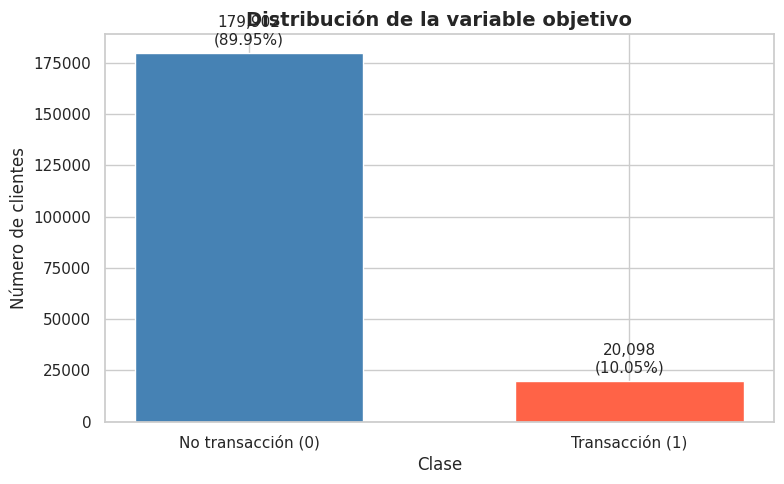

In [6]:
"""
Sección 5.1 — Distribución de la variable objetivo
==================================================

Qué hace esta celda:
- Visualiza la distribución de la variable objetivo `target`.
- Muestra tanto el número absoluto de clientes como el porcentaje de cada clase.

Por qué es importante:
  Antes de entrenar cualquier modelo, necesitamos confirmar si existe
  desbalance de clases y en qué magnitud. Esto afecta directamente a:
  - la elección de métricas,
  - la estrategia de validación,
  - la interpretación del rendimiento del modelo.
"""

# ------------------------------------------------------------
# Cálculo de frecuencias del target
# ------------------------------------------------------------

target_counts = train["target"].value_counts().sort_index()
target_pct = train["target"].value_counts(normalize=True).sort_index() * 100

# ------------------------------------------------------------
# Gráfico de barras
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["No transacción (0)", "Transacción (1)"],
    target_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="white",
    width=0.6
)

ax.set_title("Distribución de la variable objetivo", fontsize=14, fontweight="bold")
ax.set_ylabel("Número de clientes")
ax.set_xlabel("Clase")

# Etiquetas con conteo y porcentaje
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2500,
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Conclusión

La variable objetivo presenta un desbalance claro: aproximadamente **89.95%** de los clientes pertenecen a la clase 0 y **10.05%** a la clase 1.

Este resultado confirma que:

- la métrica `accuracy` no será adecuada como métrica principal,
- será más relevante utilizar **ROC-AUC** como métrica principal de competición,
- durante la evaluación también será importante analizar métricas complementarias como **precision**, **recall**, **F1-score** y **PR-AUC**,
- la validación deberá mantener la proporción de clases, por ejemplo mediante particiones estratificadas.

## 5.2 Estadística descriptiva global

Con 200 variables predictoras anonimizadas, el análisis individual de cada una aportaría poco valor en esta fase. En su lugar, se analizará la distribución de estadísticos agregados a lo largo de todas las variables.

El objetivo es revisar patrones globales en:

- **media:** permite observar el centro aproximado de cada variable;
- **desviación típica:** permite comparar el nivel de dispersión entre variables;
- **asimetría (*skewness*):** permite detectar variables con distribuciones desplazadas o colas pronunciadas.

Este enfoque permite identificar comportamientos generales, posibles anomalías y diferencias de escala sin necesidad de examinar manualmente cada variable por separado.

Dado que las variables están anonimizadas, el foco no estará en interpretar qué significa cada predictor, sino en entender su comportamiento estadístico y su posible impacto en el modelado.

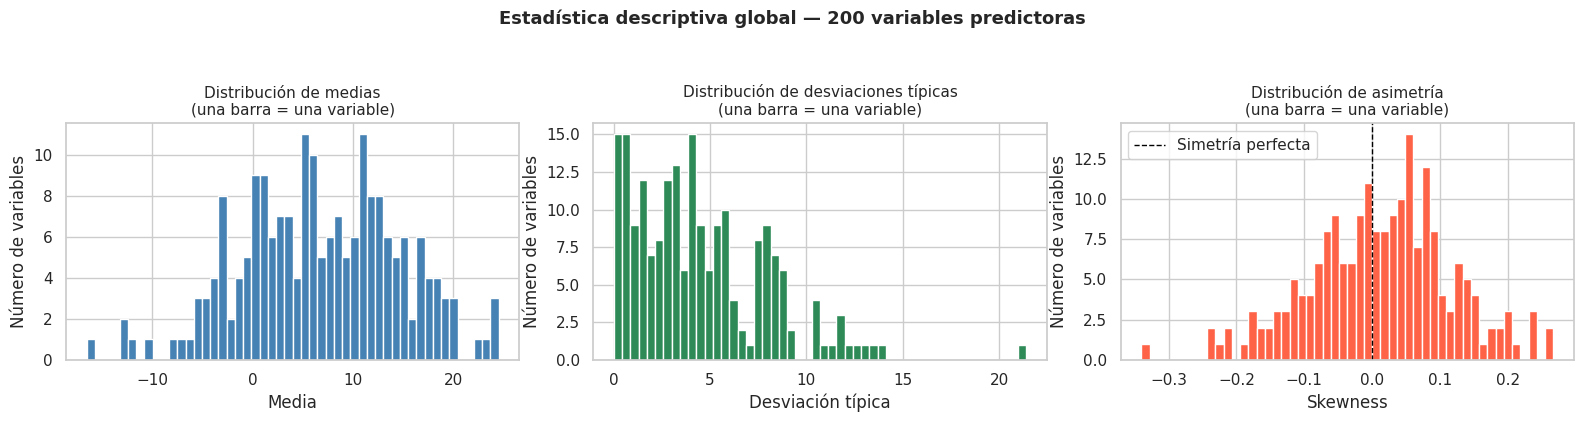

RESUMEN DE ESTADÍSTICOS GLOBALES
Media promedio de todas las variables       : 6.7674
Std promedio de todas las variables         : 4.4946
Skewness promedio absoluto                  : 0.0836
Variables con |skewness| > 1                : 0
Variables con |skewness| > 3                : 0


In [7]:
"""
Sección 5.2 — Estadística descriptiva global
============================================

Qué hace esta celda:
- Calcula estadísticos descriptivos sobre todas las variables predictoras.
- Visualiza la distribución de medias, desviaciones típicas y asimetría a lo largo de las 200 variables.

Por qué analizamos estadísticos agregados:
  Como las variables están anonimizadas, analizar una por una aportaría poco valor interpretativo.
  En su lugar, revisamos patrones globales para detectar diferencias de escala, dispersión,
  asimetrías o posibles comportamientos anómalos.

Por qué analizamos skewness:
  La asimetría mide si la distribución de una variable está sesgada hacia la izquierda o hacia la derecha.
  En modelos lineales, una fuerte asimetría puede afectar al rendimiento.
  En modelos basados en árboles, como LightGBM, este problema suele ser menos crítico,
  pero sigue siendo útil conocer la forma general de las variables.
"""

# ------------------------------------------------------------
# Selección de variables predictoras
# ------------------------------------------------------------

var_cols = [col for col in train.columns if col.startswith("var_")]

assert len(var_cols) == 200, f"Se esperaban 200 variables predictoras, pero se detectaron {len(var_cols)}"


# ------------------------------------------------------------
# Cálculo de estadísticos descriptivos
# ------------------------------------------------------------

desc = train[var_cols].describe().T
skewness = train[var_cols].skew()


# ------------------------------------------------------------
# Visualización de estadísticos globales
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de medias
axes[0].hist(
    desc["mean"],
    bins=50,
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Distribución de medias\n(una barra = una variable)", fontsize=11)
axes[0].set_xlabel("Media")
axes[0].set_ylabel("Número de variables")

# Distribución de desviaciones típicas
axes[1].hist(
    desc["std"],
    bins=50,
    color="seagreen",
    edgecolor="white"
)
axes[1].set_title("Distribución de desviaciones típicas\n(una barra = una variable)", fontsize=11)
axes[1].set_xlabel("Desviación típica")
axes[1].set_ylabel("Número de variables")

# Distribución de skewness
axes[2].hist(
    skewness,
    bins=50,
    color="tomato",
    edgecolor="white"
)
axes[2].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Simetría perfecta"
)
axes[2].set_title("Distribución de asimetría\n(una barra = una variable)", fontsize=11)
axes[2].set_xlabel("Skewness")
axes[2].set_ylabel("Número de variables")
axes[2].legend()

plt.suptitle(
    "Estadística descriptiva global — 200 variables predictoras",
    fontsize=13,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Resumen numérico
# ------------------------------------------------------------

print("=" * 60)
print("RESUMEN DE ESTADÍSTICOS GLOBALES")
print("=" * 60)

print(f"Media promedio de todas las variables       : {desc['mean'].mean():.4f}")
print(f"Std promedio de todas las variables         : {desc['std'].mean():.4f}")
print(f"Skewness promedio absoluto                  : {skewness.abs().mean():.4f}")
print(f"Variables con |skewness| > 1                : {(skewness.abs() > 1).sum()}")
print(f"Variables con |skewness| > 3                : {(skewness.abs() > 3).sum()}")

## Conclusión de la estadística descriptiva global

El análisis agregado de las 200 variables predictoras muestra que las variables presentan escalas diferentes: las medias no están centradas en cero y las desviaciones típicas varían entre predictores.

Este resultado tiene implicaciones para el modelado:

- Para modelos lineales, como una regresión logística baseline, será recomendable aplicar escalado de variables.
- Para modelos basados en árboles, como LightGBM, el escalado no es estrictamente necesario, ya que estos modelos trabajan mediante particiones de los valores.

En cuanto a la asimetría, no se detectan variables con `|skewness| > 1`, por lo que no parece necesario aplicar transformaciones logarítmicas o correcciones específicas por distribuciones fuertemente sesgadas.

En conjunto, no se observan anomalías globales graves en la forma de las variables. El siguiente paso será analizar si algunas de estas variables muestran diferencias relevantes entre la clase negativa (`target = 0`) y la clase positiva (`target = 1`).

## 5.3 Distribución de variables: clase 0 vs clase 1

Para evaluar si las variables predictoras tienen poder discriminativo,
se analiza si su distribución difiere entre la clase positiva (target=1)
y la clase negativa (target=0).

Se visualizan 6 variables representativas. El patrón observado
en estas variables es generalizable al resto del conjunto.












































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Variables seleccionadas por mayor diferencia media estandarizada:
var_81: 0.2700
var_139: 0.2471
var_12: 0.2317
var_6: 0.2224
var_110: 0.2142
var_146: 0.2121


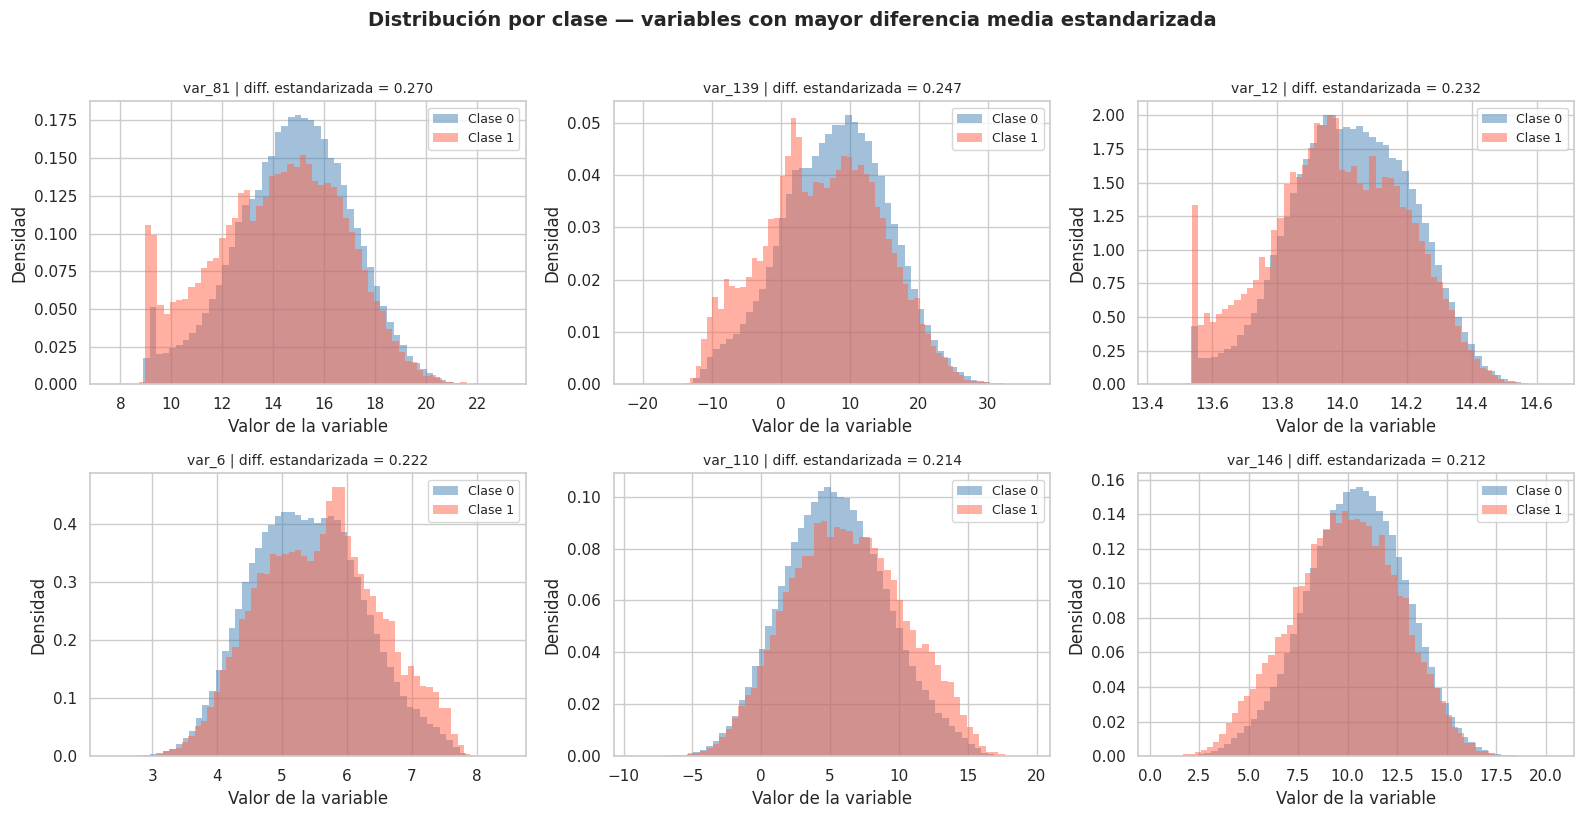

In [8]:
"""
Sección 5.3 — Distribución de variables por clase
=================================================

Qué hace esta celda:
- Calcula la diferencia media estandarizada entre clase 0 y clase 1 para cada variable.
- Selecciona las 6 variables con mayor diferencia absoluta.
- Visualiza sus distribuciones separando `target = 0` y `target = 1`.

Por qué este análisis:
  Si las distribuciones de ambas clases se solapan completamente,
  la variable aporta poca señal discriminativa de forma individual.

  Si las distribuciones muestran desplazamientos o formas distintas,
  la variable puede aportar información útil al modelo.

  Este análisis no implica causalidad: solo evalúa diferencias estadísticas
  observables entre clases.
"""

# ------------------------------------------------------------
# Cálculo de diferencia media estandarizada por variable
# ------------------------------------------------------------

clase_0 = train[train["target"] == 0]
clase_1 = train[train["target"] == 1]

mean_0 = clase_0[var_cols].mean()
mean_1 = clase_1[var_cols].mean()

std_0 = clase_0[var_cols].std()
std_1 = clase_1[var_cols].std()

n_0 = len(clase_0)
n_1 = len(clase_1)

pooled_std = np.sqrt(
    ((n_0 - 1) * std_0**2 + (n_1 - 1) * std_1**2) / (n_0 + n_1 - 2)
)

standardized_mean_diff = ((mean_1 - mean_0) / pooled_std).abs()

top_vars = standardized_mean_diff.sort_values(ascending=False).head(6).index.tolist()

print("Variables seleccionadas por mayor diferencia media estandarizada:")
for var in top_vars:
    print(f"{var}: {standardized_mean_diff[var]:.4f}")


# ------------------------------------------------------------
# Visualización de distribuciones por clase
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    datos_clase_0 = train.loc[train["target"] == 0, var]
    datos_clase_1 = train.loc[train["target"] == 1, var]

    axes[i].hist(
        datos_clase_0,
        bins=60,
        alpha=0.5,
        color="steelblue",
        label="Clase 0",
        density=True,
        edgecolor="none"
    )

    axes[i].hist(
        datos_clase_1,
        bins=60,
        alpha=0.5,
        color="tomato",
        label="Clase 1",
        density=True,
        edgecolor="none"
    )

    axes[i].set_title(
        f"{var} | diff. estandarizada = {standardized_mean_diff[var]:.3f}",
        fontsize=10
    )
    axes[i].set_xlabel("Valor de la variable")
    axes[i].set_ylabel("Densidad")
    axes[i].legend(fontsize=9)

plt.suptitle(
    "Distribución por clase — variables con mayor diferencia media estandarizada",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## Conclusión de la comparación por clase

Las variables seleccionadas muestran diferencias visibles entre la clase negativa (`target = 0`) y la clase positiva (`target = 1`), pero el solapamiento entre ambas distribuciones sigue siendo elevado.

La mayor diferencia media estandarizada se observa en `var_81`, seguida por `var_139`, `var_12`, `var_6`, `var_110` y `var_146`. Sin embargo, ninguna de estas variables separa por sí sola a los clientes que transaccionan de los que no.

Este patrón sugiere que el problema no depende de una única variable claramente discriminativa, sino de la combinación de muchas señales débiles distribuidas entre distintos predictores.

Implicaciones para el modelado:

- Un modelo lineal puede capturar parte de la señal si las diferencias son aproximadamente aditivas.
- Un modelo basado en árboles, como LightGBM, puede aprovechar interacciones no lineales y combinaciones de variables.
- La evaluación debe centrarse en la capacidad global del modelo para ordenar clientes por probabilidad, no en la interpretación aislada de variables individuales.

Dado que las variables están anonimizadas, estas diferencias deben interpretarse como evidencia estadística de señal predictiva, no como una explicación causal del comportamiento del cliente.

## 5.4 Hallazgo clave: detección de filas sintéticas en test

Uno de los hallazgos más relevantes de esta competición, documentado por la comunidad de participantes de Kaggle, es que el conjunto de test parece contener observaciones reales y observaciones sintéticas.

El patrón observado sugiere que una parte del test fue generada artificialmente a partir de valores ya presentes en el propio conjunto de test. Esto provoca duplicaciones anómalas en variables que, por su naturaleza continua, deberían tener una frecuencia de repetición mucho menor.

Este hallazgo tiene implicaciones directas en el feature engineering. Si somos capaces de identificar las filas reales del test, podemos construir variables de frecuencia basadas únicamente en la distribución real de los datos, evitando que las filas sintéticas distorsionen esas frecuencias.

Es importante aclarar que esta estrategia pertenece al contexto específico de una competición de Kaggle. En un entorno real de producción, utilizar información del conjunto de predicción para construir features debe analizarse con mucho cuidado, ya que podría introducir leakage o supuestos no válidos.

En esta sección se detecta y cuantifica este fenómeno. Su explotación para crear nuevas variables se abordará en la sección de Feature Engineering.

FRECUENCIA DE APARICIÓN DE VALORES EN var_0 — TEST
count
1     15068
2     17639
3     12389
4      7899
5      5001
6      3092
7      1863
8      1163
9       641
10      374
11      210
12      111
13       58
14       32
15       18
Name: count, dtype: int64

VALORES ÚNICOS
Valores únicos en test  (var_0): 65,580
Valores únicos en train (var_0): 94,672


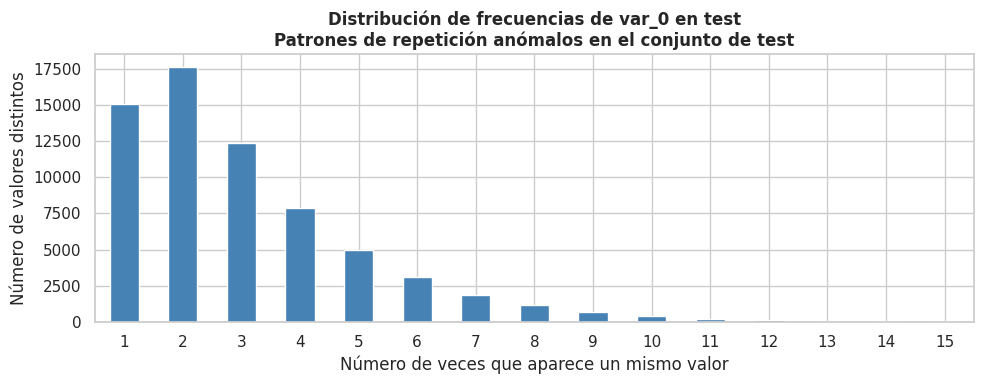

In [9]:
"""
Sección 5.4A — Diagnóstico visual de duplicación en test
========================================================

Qué hace esta celda:
- Analiza cuántas veces aparece cada valor de `var_0` en el conjunto de test.
- Visualiza la distribución de frecuencias de aparición.

Por qué este análisis:
  En variables continuas, lo esperable es que muchos valores aparezcan pocas veces.
  Si aparecen patrones fuertes de duplicación, puede ser una señal de filas sintéticas
  o de valores generados artificialmente.

Importante:
  Esta celda solo muestra el patrón con una variable (`var_0`).
  La detección robusta de filas reales se realizará después usando las 200 variables.
"""

# ------------------------------------------------------------
# Frecuencia de aparición de valores en var_0
# ------------------------------------------------------------

counts_var0 = test["var_0"].value_counts()
freq_distribution = counts_var0.value_counts().sort_index()

print("=" * 60)
print("FRECUENCIA DE APARICIÓN DE VALORES EN var_0 — TEST")
print("=" * 60)

print(freq_distribution.head(15))

print("\n" + "=" * 60)
print("VALORES ÚNICOS")
print("=" * 60)

print(f"Valores únicos en test  (var_0): {test['var_0'].nunique():,}")
print(f"Valores únicos en train (var_0): {train['var_0'].nunique():,}")


# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

freq_distribution.head(15).plot(
    kind="bar",
    color="steelblue",
    edgecolor="white"
)

plt.title(
    "Distribución de frecuencias de var_0 en test\n"
    "Patrones de repetición anómalos en el conjunto de test",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Número de veces que aparece un mismo valor")
plt.ylabel("Número de valores distintos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
"""
Sección 5.4B — Detección robusta de filas reales en test
========================================================

Qué hace esta celda:
- Identifica filas reales del test usando las 200 variables predictoras.
- Una fila se marca como real si contiene al menos un valor único en alguna variable.
- Separa el test en dos subconjuntos:
  - test_real
  - test_synthetic

Por qué funciona:
  Si una fila contiene un valor único en alguna variable continua, es muy probable
  que sea una observación real. Las filas sintéticas tienden a estar formadas por
  valores ya repetidos en el conjunto de test.
"""

# ------------------------------------------------------------
# Inicialización de máscara de filas reales
# ------------------------------------------------------------

real_test_mask = pd.Series(False, index=test.index)

# ------------------------------------------------------------
# Detección de valores únicos por variable
# ------------------------------------------------------------

for col in var_cols:
    value_counts = test[col].value_counts()
    unique_values = value_counts[value_counts == 1].index

    real_test_mask |= test[col].isin(unique_values)

# ------------------------------------------------------------
# Separación de test real y sintético
# ------------------------------------------------------------

test_real = test.loc[real_test_mask].copy()
test_synthetic = test.loc[~real_test_mask].copy()

real_test_idx = test_real.index
synthetic_test_idx = test_synthetic.index

# Añadimos una marca auxiliar al test completo
test["is_real_test"] = real_test_mask.astype(int)

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

n_real = real_test_mask.sum()
n_synthetic = (~real_test_mask).sum()

pct_real = n_real / len(test) * 100
pct_synthetic = n_synthetic / len(test) * 100

print("=" * 60)
print("DETECCIÓN DE FILAS REALES Y SINTÉTICAS EN TEST")
print("=" * 60)

print(f"Filas totales en test      : {len(test):,}")
print(f"Filas detectadas como reales     : {n_real:,} ({pct_real:.2f}%)")
print(f"Filas detectadas como sintéticas : {n_synthetic:,} ({pct_synthetic:.2f}%)")

print("\nValidación:")
print(f"test_real shape      : {test_real.shape}")
print(f"test_synthetic shape : {test_synthetic.shape}")

DETECCIÓN DE FILAS REALES Y SINTÉTICAS EN TEST
Filas totales en test      : 200,000
Filas detectadas como reales     : 100,000 (50.00%)
Filas detectadas como sintéticas : 100,000 (50.00%)

Validación:
test_real shape      : (100000, 201)
test_synthetic shape : (100000, 201)


## Conclusión sobre filas sintéticas en test

El análisis confirma un patrón muy relevante en el conjunto de test: al aplicar la detección sobre las 200 variables predictoras, el dataset se divide exactamente en dos grupos de igual tamaño:

- **100.000 filas detectadas como reales**
- **100.000 filas detectadas como sintéticas**

Este resultado es consistente con el hallazgo documentado por la comunidad de Kaggle durante la competición: el conjunto de test contiene observaciones reales y observaciones compatibles con generación sintética.

La detección no se basa únicamente en observar si un valor aparece un número par o impar de veces en una variable concreta. La estrategia robusta consiste en revisar las 200 variables y marcar una fila como real cuando contiene al menos un valor único dentro del conjunto de test.

Este hallazgo tiene una implicación directa para el feature engineering: las filas sintéticas pueden distorsionar las frecuencias de aparición de valores. Por tanto, en la siguiente sección se utilizará el subconjunto `test_real` como referencia para construir variables de frecuencia más informativas.

Es importante aclarar que las filas sintéticas no se eliminan del conjunto de test final. La submission de Kaggle debe contener predicciones para las 200.000 filas. La separación entre `test_real` y `test_synthetic` se utiliza únicamente para construir features de forma más limpia.

Desde el punto de vista de negocio, esta técnica debe interpretarse con cautela. Es una estrategia válida dentro del contexto específico de una competición de Kaggle, donde el conjunto de test está disponible sin etiquetas. En un entorno real de producción, utilizar información del conjunto de predicción para construir variables requeriría una validación adicional para evitar leakage o supuestos no reproducibles.

# 6. Feature Engineering

El Feature Engineering es una etapa relevante en este proyecto. Las 200 variables anonimizadas se utilizarán como base, pero se construirán variables adicionales para capturar información que no está representada explícitamente en los valores brutos.

La técnica principal será **Frequency Encoding**. Para cada variable y cada observación, se calculará cuántas veces aparece ese valor exacto dentro del subconjunto de filas reales del test (`test_real`).

Este conteo permite codificar la frecuencia o rareza relativa de cada valor. En este dataset, esa información resulta especialmente relevante porque el conjunto de test contiene filas sintéticas que alteran artificialmente la distribución de frecuencias.

El proceso seguirá dos pasos:

1. Usar la detección realizada en el EDA para aislar las filas reales del test (`test_real`).
2. Calcular variables de frecuencia usando únicamente `test_real` como referencia.

Después, estas nuevas variables se añadirán tanto a `train` como a `test`, de forma que ambos conjuntos mantengan la misma estructura para el modelado y la generación de la submission.

Es importante destacar que esta estrategia pertenece al contexto de Kaggle. En un entorno productivo real, utilizar información del conjunto de predicción para construir variables debería evaluarse cuidadosamente para evitar leakage o supuestos que no puedan reproducirse en producción.

## 6.1 Identificación de filas reales en test

Como se documentó en la sección 5.4, el conjunto de test contiene 200.000 filas, de las cuales 100.000 han sido detectadas como reales y 100.000 como sintéticas.

Antes de construir variables de frecuencia, es necesario utilizar únicamente las filas reales como referencia. Si se calculasen frecuencias sobre el test completo, las filas sintéticas distorsionarían los conteos y reducirían la calidad de la señal generada.

La detección ya se realizó en el EDA mediante una máscara booleana (`real_test_mask`), que identifica como reales aquellas filas que contienen al menos un valor único en alguna de las 200 variables predictoras.

En esta sección no se repite el razonamiento exploratorio, sino que se reutiliza el subconjunto `test_real` como base para el Frequency Encoding.

Punto importante: las filas sintéticas no se eliminan del conjunto de test final. El modelo deberá generar predicciones para todas las filas de `test`, ya que Kaggle espera una submission con 200.000 observaciones.

In [11]:
"""
Sección 6.1 — Validación de filas reales para Feature Engineering
=================================================================

Qué hace esta celda:
- Reutiliza la detección realizada en la sección 5.4.
- Reconstruye `test_real` y `test_synthetic` de forma limpia.
- Verifica que la separación entre filas reales y sintéticas es consistente.

Por qué no repetimos la detección:
  La identificación de filas reales ya fue realizada y explicada durante el EDA.
  En Feature Engineering solo necesitamos reutilizar esa máscara para construir
  variables de frecuencia sin que las filas sintéticas distorsionen los conteos.

Importante:
  Las filas sintéticas no se eliminan del test final.
  Kaggle exige predicciones para las 200.000 filas.
"""

# ------------------------------------------------------------
# Validación de objetos creados en el EDA
# ------------------------------------------------------------

if "real_test_mask" not in globals():
    raise NameError(
        "No existe real_test_mask. Ejecuta primero la sección 5.4B "
        "de detección de filas reales en test."
    )

assert len(real_test_mask) == len(test), "real_test_mask no tiene la misma longitud que test"
assert real_test_mask.dtype == bool, "real_test_mask debe ser una máscara booleana"

# ------------------------------------------------------------
# Reconstrucción limpia de test_real y test_synthetic
# ------------------------------------------------------------

columnas_test_base = ["ID_code"] + var_cols

test_real = test.loc[real_test_mask, columnas_test_base].copy()
test_synthetic = test.loc[~real_test_mask, columnas_test_base].copy()

real_test_idx = test_real.index
synthetic_test_idx = test_synthetic.index

# ------------------------------------------------------------
# Validación de resultados
# ------------------------------------------------------------

n_real = len(test_real)
n_synthetic = len(test_synthetic)

print("=" * 60)
print("VALIDACIÓN DE FILAS REALES PARA FEATURE ENGINEERING")
print("=" * 60)

print(f"Filas totales en test              : {len(test):,}")
print(f"Filas reales identificadas         : {n_real:,} ({n_real / len(test) * 100:.2f}%)")
print(f"Filas sintéticas identificadas     : {n_synthetic:,} ({n_synthetic / len(test) * 100:.2f}%)")

assert n_real + n_synthetic == len(test), "La suma de reales y sintéticas no coincide con test"
assert n_real == 100_000, f"Se esperaban 100.000 filas reales, pero se detectaron {n_real:,}"
assert n_synthetic == 100_000, f"Se esperaban 100.000 filas sintéticas, pero se detectaron {n_synthetic:,}"

print("\n✅ test_real y test_synthetic preparados correctamente")
print("✅ test_real se usará como referencia para el Frequency Encoding")

VALIDACIÓN DE FILAS REALES PARA FEATURE ENGINEERING
Filas totales en test              : 200,000
Filas reales identificadas         : 100,000 (50.00%)
Filas sintéticas identificadas     : 100,000 (50.00%)

✅ test_real y test_synthetic preparados correctamente
✅ test_real se usará como referencia para el Frequency Encoding


La identificación confirma que el conjunto de test se divide exactamente en dos partes:

- **100.000 filas detectadas como reales**
- **100.000 filas detectadas como sintéticas**

Este resultado es consistente con lo documentado por la comunidad de Kaggle durante esta competición.

A partir de este punto, las variables de frecuencia que utilicen información del test se calcularán exclusivamente sobre `test_real`. De esta forma, se evita que las filas sintéticas distorsionen los conteos y reduzcan la calidad de la señal generada.

Esta decisión pertenece al contexto específico de Kaggle: el test está disponible sin etiquetas y puede analizarse para construir features transductivas. En un entorno real, esta estrategia requeriría validación adicional para asegurar que no introduce leakage ni dependencias no reproducibles en producción.

## 6.2 Frequency Encoding

Una vez identificadas las filas reales del conjunto de test, se construyen variables de frecuencia para cada una de las 200 variables predictoras.

La técnica utilizada es **Frequency Encoding**. Para cada variable `var_i`, se calcula cuántas veces aparece cada valor exacto dentro de `test_real`. Ese conteo se añade como una nueva variable llamada `var_i_freq`.

Por ejemplo, si un valor concreto de `var_0` aparece 5 veces en `test_real`, cualquier fila de `train` o `test` que tenga ese mismo valor en `var_0` recibirá `var_0_freq = 5`.

Si un valor no aparece en `test_real`, su frecuencia se codifica como `0`.

El objetivo de estas nuevas variables es capturar información sobre la rareza o frecuencia relativa de cada valor dentro de la parte real del test. En este dataset, esa información contiene señal predictiva relevante debido a la estructura artificial detectada en el conjunto de test.

El proceso genera:

- 200 variables originales (`var_0` a `var_199`);
- 200 variables de frecuencia (`var_0_freq` a `var_199_freq`);
- 400 variables predictoras en total para el modelado.

Esta técnica se aplica tanto a `train` como a `test` para mantener la misma estructura de columnas en ambos conjuntos.

Como se ha indicado anteriormente, este enfoque es específico del contexto Kaggle. En un entorno productivo real, usar información del conjunto de predicción para crear variables requeriría una validación adicional para evitar leakage o dependencias no reproducibles.

In [12]:
"""
Sección 6.2 — Frequency Encoding
================================

Qué hace esta celda:
- Construye 200 variables de frecuencia para train y test.
- Calcula las frecuencias usando únicamente `test_real`.
- Añade las nuevas columnas de una sola vez con `pd.concat`.

Por qué usamos test_real:
  Las filas sintéticas del test distorsionan las frecuencias de aparición.
  Por eso, el mapa de frecuencias se calcula solo sobre las filas reales.

Por qué usamos pd.concat:
  Añadir columnas dentro de un bucle puede fragmentar la memoria del DataFrame
  y generar PerformanceWarning en pandas. Construir primero los diccionarios
  de columnas y concatenar una sola vez es más eficiente.
"""

# ------------------------------------------------------------
# Validaciones previas
# ------------------------------------------------------------

assert "test_real" in globals(), "test_real no existe. Ejecuta primero la sección 6.1"
assert len(var_cols) == 200, f"Se esperaban 200 variables predictoras, pero hay {len(var_cols)}"
assert len(test_real) == 100_000, f"Se esperaban 100.000 filas reales en test_real, pero hay {len(test_real):,}"


# ------------------------------------------------------------
# Construcción de diccionarios de frecuencias
# ------------------------------------------------------------

freq_dict_train = {}
freq_dict_test = {}

for var in var_cols:
    freq_map = test_real[var].value_counts()

    freq_dict_train[f"{var}_freq"] = train[var].map(freq_map).fillna(0).astype(int)
    freq_dict_test[f"{var}_freq"] = test[var].map(freq_map).fillna(0).astype(int)


# ------------------------------------------------------------
# Concatenación eficiente de nuevas variables
# ------------------------------------------------------------

train_fe = pd.concat(
    [train, pd.DataFrame(freq_dict_train, index=train.index)],
    axis=1
)

test_fe = pd.concat(
    [test, pd.DataFrame(freq_dict_test, index=test.index)],
    axis=1
)


# ------------------------------------------------------------
# Validación de estructura final
# ------------------------------------------------------------

freq_cols = [col for col in train_fe.columns if col.endswith("_freq")]
feature_cols = var_cols + freq_cols

print("=" * 60)
print("VALIDACIÓN DE FREQUENCY ENCODING")
print("=" * 60)

print(f"Variables originales             : {len(var_cols)}")
print(f"Variables de frecuencia          : {len(freq_cols)}")
print(f"Total variables predictoras      : {len(feature_cols)}")
print(f"Columnas totales en train_fe     : {train_fe.shape[1]}")
print(f"Columnas totales en test_fe      : {test_fe.shape[1]}")

assert len(freq_cols) == 200, f"Se esperaban 200 variables de frecuencia, pero hay {len(freq_cols)}"
assert len(feature_cols) == 400, f"Se esperaban 400 variables predictoras, pero hay {len(feature_cols)}"
assert train_fe.shape[0] == train.shape[0], "train_fe no conserva el número de filas de train"
assert test_fe.shape[0] == test.shape[0], "test_fe no conserva el número de filas de test"

nulos_freq_train = train_fe[freq_cols].isna().sum().sum()
nulos_freq_test = test_fe[freq_cols].isna().sum().sum()

assert nulos_freq_train == 0, "Hay nulos en variables de frecuencia de train_fe"
assert nulos_freq_test == 0, "Hay nulos en variables de frecuencia de test_fe"

print("\n✅ Frequency Encoding construido correctamente")
print("✅ train_fe y test_fe mantienen el mismo número de filas que los datasets originales")
print("✅ No hay nulos en las variables de frecuencia")

print("\nEjemplo — primeras 5 frecuencias de var_0:")
display(train_fe[["var_0", "var_0_freq"]].head())

VALIDACIÓN DE FREQUENCY ENCODING
Variables originales             : 200
Variables de frecuencia          : 200
Total variables predictoras      : 400
Columnas totales en train_fe     : 402
Columnas totales en test_fe      : 402

✅ Frequency Encoding construido correctamente
✅ train_fe y test_fe mantienen el mismo número de filas que los datasets originales
✅ No hay nulos en las variables de frecuencia

Ejemplo — primeras 5 frecuencias de var_0:


,var_0,var_0_freq
0,8.9255,2
1,11.5006,1
2,8.6093,2
3,11.0604,0
4,9.8369,5


## Conclusión del Frequency Encoding

El proceso de Frequency Encoding ha generado correctamente **200 nuevas variables de frecuencia**, una por cada variable predictora original.

El dataset pasa de:

- **200 variables originales** (`var_0` a `var_199`)
- a **400 variables predictoras totales**, al añadir `var_0_freq` a `var_199_freq`.

Estas nuevas variables codifican cuántas veces aparece cada valor exacto dentro de `test_real`, permitiendo capturar información sobre rareza o frecuencia relativa de los valores.

No se detectan valores nulos en las variables generadas y tanto `train_fe` como `test_fe` mantienen el mismo número de filas que los datasets originales.

A partir de este punto, el modelado utilizará exclusivamente las variables incluidas en `feature_cols`, evitando columnas auxiliares como `ID_code`, `target` o `is_real_test`.

In [13]:
# Validación final de columnas usadas para modelado
columnas_prohibidas = {"ID_code", "target", "is_real_test"}

columnas_prohibidas_en_features = columnas_prohibidas.intersection(feature_cols)

assert len(columnas_prohibidas_en_features) == 0, (
    f"Hay columnas no permitidas en feature_cols: {columnas_prohibidas_en_features}"
)

assert set(feature_cols).issubset(train_fe.columns), "Hay features que no están en train_fe"
assert set(feature_cols).issubset(test_fe.columns), "Hay features que no están en test_fe"

print("✅ feature_cols contiene únicamente variables predictoras válidas")
print(f"Total de variables usadas para modelado: {len(feature_cols)}")

✅ feature_cols contiene únicamente variables predictoras válidas
Total de variables usadas para modelado: 400


# 7. Preprocesado y Pipeline

A diferencia de otros datasets con variables categóricas, valores nulos o formatos heterogéneos, este proyecto requiere un preprocesado relativamente simple.

La auditoría técnica confirmó que:

- no hay valores nulos en `train` ni en `test`;
- todas las variables predictoras son numéricas;
- no existen variables categóricas explícitas;
- las columnas utilizadas para modelado están controladas en `feature_cols`.

Por tanto, no será necesario aplicar imputación ni encoding categórico.

El punto principal de preprocesado será el **escalado selectivo**:

- Para modelos lineales, como la regresión logística baseline, se aplicará `StandardScaler` dentro de un `Pipeline` de scikit-learn.
- Para modelos basados en árboles, como LightGBM, no se aplicará estandarización, ya que estos modelos no dependen de la escala de las variables de la misma forma que los modelos lineales.

El uso de `Pipeline` permite asegurar que las transformaciones ajustadas durante el entrenamiento se calculan únicamente sobre el conjunto de entrenamiento y se aplican después al conjunto de validación. Esto reduce el riesgo de leakage en el baseline logístico.

Es importante diferenciar este punto del Frequency Encoding realizado previamente. El uso de `test_real` para crear variables de frecuencia pertenece al contexto específico de Kaggle y fue tratado como una decisión de Feature Engineering transductivo. En esta sección, el objetivo es preparar matrices limpias y consistentes para entrenar y evaluar los modelos.

## 7.1 Separación train/validation

Se separa el dataset de entrenamiento en dos particiones:

- **Train (80%)**: utilizado para ajustar el modelo.
- **Validation (20%)**: utilizado para evaluar el rendimiento del modelo sin usar las etiquetas del test de Kaggle.

La partición se realiza de forma **estratificada** para mantener la proporción original del `target` en ambos conjuntos. Esto es importante porque la clase positiva representa aproximadamente un 10% de las observaciones.

El split se realiza sobre `train_fe`, es decir, sobre el dataset enriquecido con las 400 variables predictoras:

- 200 variables originales;
- 200 variables de frecuencia generadas mediante Frequency Encoding.

El objetivo de esta partición es obtener una primera estimación del rendimiento del modelo en datos no vistos durante el entrenamiento. Más adelante, una validación más robusta podría realizarse mediante **Stratified K-Fold Cross Validation**.

In [14]:
"""
Sección 7.1 — Separación train/validation
=========================================

Qué hace esta celda:
- Separa train_fe en conjunto de entrenamiento y validación.
- Usa partición estratificada para mantener la proporción del target.
- Prepara también X_test para la futura submission de Kaggle.

Por qué separamos después del Feature Engineering:
  El Frequency Encoding construido previamente usa información del test real,
  pero no utiliza el target de train ni etiquetas del test. Por tanto, dentro
  del contexto Kaggle, calcularlo antes del split no introduce leakage de target.

  Si estuviéramos usando técnicas dependientes del target, como target encoding,
  el split debería hacerse antes de calcular esas transformaciones.
"""

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# Definición de columnas principales
# ------------------------------------------------------------

TARGET = "target"
ID_COL = "ID_code"

# Usamos la lista de features ya validada previamente
feature_cols = var_cols + freq_cols

columnas_prohibidas = {TARGET, ID_COL, "is_real_test"}
columnas_prohibidas_en_features = columnas_prohibidas.intersection(feature_cols)

assert len(columnas_prohibidas_en_features) == 0, (
    f"Hay columnas no permitidas en feature_cols: {columnas_prohibidas_en_features}"
)

assert set(feature_cols).issubset(train_fe.columns), "Hay features que no están en train_fe"
assert set(feature_cols).issubset(test_fe.columns), "Hay features que no están en test_fe"


# ------------------------------------------------------------
# Matrices de modelado
# ------------------------------------------------------------

X = train_fe[feature_cols].copy()
y = train_fe[TARGET].copy()

X_test = test_fe[feature_cols].copy()


# ------------------------------------------------------------
# Split estratificado train/validation
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)


# ------------------------------------------------------------
# Validación del split
# ------------------------------------------------------------

print("=" * 60)
print("VALIDACIÓN DEL SPLIT TRAIN / VALIDATION")
print("=" * 60)

print(f"X_train : {X_train.shape[0]:,} filas · {X_train.shape[1]} features")
print(f"X_val   : {X_val.shape[0]:,} filas · {X_val.shape[1]} features")
print(f"X_test  : {X_test.shape[0]:,} filas · {X_test.shape[1]} features")

print("\nDistribución del target:")
print(f"Target mean train : {y_train.mean():.4f}")
print(f"Target mean val   : {y_val.mean():.4f}")
print(f"Target mean total : {y.mean():.4f}")

assert X_train.shape[1] == 400, f"X_train debería tener 400 features, pero tiene {X_train.shape[1]}"
assert X_val.shape[1] == 400, f"X_val debería tener 400 features, pero tiene {X_val.shape[1]}"
assert X_test.shape[1] == 400, f"X_test debería tener 400 features, pero tiene {X_test.shape[1]}"

assert abs(y_train.mean() - y.mean()) < 0.001, "La proporción del target en train cambia demasiado"
assert abs(y_val.mean() - y.mean()) < 0.001, "La proporción del target en validation cambia demasiado"

print("\n✅ Split estratificado realizado correctamente")
print("✅ X_train, X_val y X_test contienen las mismas 400 features")

VALIDACIÓN DEL SPLIT TRAIN / VALIDATION
X_train : 160,000 filas · 400 features
X_val   : 40,000 filas · 400 features
X_test  : 200,000 filas · 400 features

Distribución del target:
Target mean train : 0.1005
Target mean val   : 0.1005
Target mean total : 0.1005

✅ Split estratificado realizado correctamente
✅ X_train, X_val y X_test contienen las mismas 400 features


## 7.2 Estandarización

LightGBM, al ser un modelo basado en árboles, no requiere estandarización. Este tipo de modelo toma decisiones mediante umbrales sobre las variables, por lo que no depende de que todas estén en la misma escala.

Sin embargo, el modelo baseline de Regresión Logística sí es sensible a la escala de las variables. Dado que las 400 variables predictoras presentan rangos y dispersiones diferentes, aplicar estandarización ayuda a mejorar la estabilidad y la convergencia del optimizador.

Para evitar contaminación entre particiones, la estandarización se aplicará dentro de un `Pipeline` de scikit-learn:

- el `StandardScaler` se ajustará únicamente sobre `X_train`;
- la transformación aprendida se aplicará después sobre `X_val`;
- el escalado formará parte del entrenamiento y evaluación del baseline logístico, no del modelo LightGBM.

Este enfoque garantiza que el baseline logístico se evalúe de forma limpia, sin usar información de validación durante el ajuste del preprocesado.

# 8. Modelado

En esta sección se entrenan modelos siguiendo una estrategia incremental: primero se construye un baseline sencillo y después se entrena un modelo más potente.

El objetivo no es solo obtener una métrica alta, sino comprobar que cada aumento de complejidad aporta valor real frente a una referencia inicial.

Se entrenarán dos modelos principales:

1. **Baseline: Regresión Logística**  
   Modelo lineal que sirve como punto de referencia.  
   Permite comprobar si las variables originales y las variables de frecuencia contienen señal predictiva suficiente incluso bajo una hipótesis lineal.

   Aunque la regresión logística es más interpretable que modelos complejos, en este dataset la interpretación de coeficientes debe tratarse con cautela, ya que las variables están completamente anonimizadas.

2. **Modelo principal: LightGBM**  
   Modelo de gradient boosting basado en árboles, especialmente competitivo en datos tabulares.  
   Su ventaja principal es que puede capturar relaciones no lineales e interacciones entre variables que un modelo lineal no puede representar de forma directa.

Ambos modelos se evaluarán sobre la misma partición de validación y con las mismas métricas, para garantizar una comparación consistente.

La métrica principal será **ROC-AUC**, alineada con la competición de Kaggle. Además, se analizarán métricas complementarias como precision, recall, F1-score y PR-AUC para entender mejor el comportamiento del modelo desde una perspectiva de negocio.

## 8.0 Función de evaluación común

Para garantizar comparaciones consistentes entre modelos, se define una función única de evaluación.

Esta función calculará métricas de dos tipos:

1. **Métricas independientes del umbral**
   - `ROC-AUC`: métrica principal de la competición Kaggle. Evalúa la capacidad del modelo para ordenar correctamente los casos positivos por encima de los negativos.
   - `Average Precision`: métrica especialmente útil en problemas con clase positiva minoritaria, ya que resume la relación entre precision y recall.

2. **Métricas dependientes del umbral**
   - `precision`
   - `recall`
   - `F1-score`
   - matriz de confusión

Esta separación es importante porque un modelo puede tener buen ROC-AUC, pero comportarse de forma distinta según el umbral elegido para convertir probabilidades en clases.

Desde el punto de vista de negocio, el umbral no es una decisión puramente técnica: depende del coste relativo entre falsos positivos y falsos negativos.

In [15]:
"""
Sección 8.0 — Función de evaluación común
=========================================

Qué hace esta celda:
- Define una función centralizada para evaluar clasificadores binarios.
- Calcula métricas independientes del umbral: ROC-AUC y Average Precision.
- Calcula métricas dependientes del umbral: precision, recall y F1-score.
- Genera visualizaciones comunes: curva ROC, curva Precision-Recall y matriz de confusión.

Por qué centralizamos la evaluación:
  Usar una única función evita comparar modelos con criterios distintos.
  Esto hace que la comparación entre baseline y LightGBM sea más limpia,
  trazable y defendible.
"""

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)


def eval_modelo(nombre, y_true, proba, th=0.5):
    """
    Evalúa un clasificador binario a partir de probabilidades.

    Parámetros
    ----------
    nombre : str
        Nombre del modelo evaluado.
    y_true : array-like
        Etiquetas reales.
    proba : array-like
        Probabilidades predichas para la clase positiva.
    th : float, default=0.5
        Umbral usado para convertir probabilidades en clase 0/1.

    Retorna
    -------
    dict
        Diccionario con las métricas principales del modelo.
    """

    # ------------------------------------------------------------
    # Validaciones básicas
    # ------------------------------------------------------------

    proba = np.asarray(proba)
    y_true = np.asarray(y_true)

    assert len(y_true) == len(proba), "y_true y proba deben tener la misma longitud"
    assert 0 <= th <= 1, "El umbral debe estar entre 0 y 1"

    if proba.min() < 0 or proba.max() > 1:
        print("⚠️ Aviso: las probabilidades están fuera del rango [0, 1]")

    # ------------------------------------------------------------
    # Conversión de probabilidades a clases
    # ------------------------------------------------------------

    y_pred = (proba >= th).astype(int)

    # ------------------------------------------------------------
    # Métricas
    # ------------------------------------------------------------

    roc = roc_auc_score(y_true, proba)
    avg_precision = average_precision_score(y_true, proba)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ------------------------------------------------------------
    # Resultados por consola
    # ------------------------------------------------------------

    print("=" * 60)
    print(f"MODELO: {nombre}")
    print("=" * 60)

    print(f"ROC-AUC           : {roc:.4f}")
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"Umbral            : {th:.2f}")

    print("\nMétricas con umbral aplicado:")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # ------------------------------------------------------------
    # Visualizaciones
    # ------------------------------------------------------------

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    RocCurveDisplay.from_predictions(
        y_true,
        proba,
        ax=axes[0],
        name=nombre
    )
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[0].set_title(f"Curva ROC — {nombre}")

    PrecisionRecallDisplay.from_predictions(
        y_true,
        proba,
        ax=axes[1],
        name=nombre
    )
    axes[1].set_title(f"Curva Precision-Recall — {nombre}")

    cm = confusion_matrix(y_true, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Clase 0", "Clase 1"]
    ).plot(
        ax=axes[2],
        values_format=",d",
        colorbar=False
    )
    axes[2].set_title(f"Matriz de confusión — umbral {th:.2f}")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Salida estructurada
    # ------------------------------------------------------------

    return {
        "modelo": nombre,
        "roc_auc": roc,
        "average_precision": avg_precision,
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 8.1 Baseline: Regresión Logística

La Regresión Logística se utiliza como modelo baseline para establecer una primera referencia de rendimiento.

Este modelo permite comprobar si las variables disponibles —incluyendo las variables originales y las variables de frecuencia— contienen señal predictiva suficiente bajo una relación aproximadamente lineal.

Dado el desbalance de clases observado en el dataset, se utiliza `class_weight="balanced"`. Este parámetro ajusta automáticamente el peso de cada clase durante el entrenamiento, de forma que la clase minoritaria tenga mayor influencia en la función de pérdida.

La estandarización se aplica dentro de un `Pipeline`, junto con el modelo, para asegurar que el `StandardScaler` se ajusta únicamente sobre `X_train` y se aplica después sobre `X_val`.

Aunque la Regresión Logística es más interpretable que modelos basados en boosting, en este caso la interpretación de coeficientes debe hacerse con cautela, ya que las variables están completamente anonimizadas.

Entrenando Regresión Logística baseline...
MODELO: Regresión Logística baseline
ROC-AUC           : 0.8626
Average Precision : 0.5072
Umbral            : 0.50

Métricas con umbral aplicado:
Precision         : 0.2911
Recall            : 0.7754
F1-score          : 0.4233

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.79     40000
   macro avg       0.63      0.78      0.65     40000
weighted avg       0.90      0.79      0.83     40000



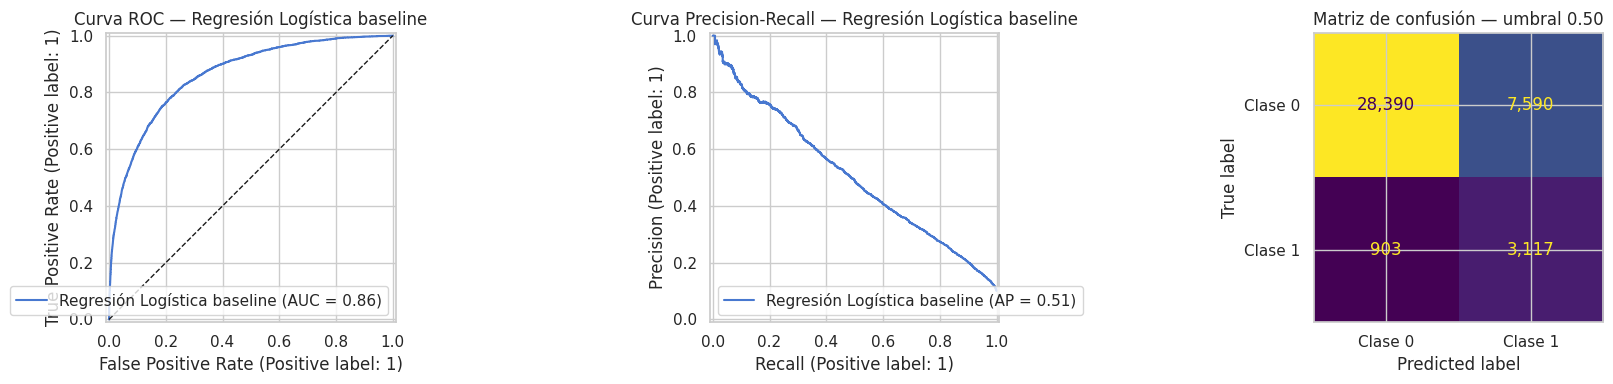

In [16]:
"""
Sección 8.1 — Baseline: Regresión Logística
===========================================

Qué hace esta celda:
- Entrena una Regresión Logística como modelo baseline.
- Aplica estandarización dentro de un Pipeline.
- Evalúa el modelo en el conjunto de validación usando la función común.

Por qué class_weight="balanced":
  Con un desbalance aproximado de 9:1, un modelo sin ajuste de pesos
  puede tender a favorecer la clase mayoritaria. El parámetro "balanced"
  ajusta los pesos de clase de forma inversamente proporcional a su frecuencia.

Por qué Pipeline:
  El StandardScaler se ajusta únicamente sobre X_train durante el entrenamiento
  y se aplica después a X_val. Esto evita contaminación entre particiones.
"""

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Definición del pipeline baseline
# ------------------------------------------------------------

lr_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ]
)


# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

print("Entrenando Regresión Logística baseline...")

lr_pipeline.fit(X_train, y_train)


# ------------------------------------------------------------
# Predicción en validación
# ------------------------------------------------------------

proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]


# ------------------------------------------------------------
# Evaluación
# ------------------------------------------------------------

res_lr = eval_modelo(
    nombre="Regresión Logística baseline",
    y_true=y_val,
    proba=proba_lr,
    th=0.5
)

## Conclusión del baseline logístico

La Regresión Logística obtiene un **ROC-AUC de 0.8626**, lo que indica que incluso un modelo lineal es capaz de capturar señal predictiva relevante en las variables disponibles.

El resultado confirma que las variables originales y las variables de frecuencia contienen información útil para discriminar entre clientes que transaccionan y clientes que no.

Con el umbral por defecto de `0.50`, el modelo consigue un **recall elevado para la clase positiva** (`0.7754`), detectando una parte importante de los clientes que sí realizarán la transacción. Sin embargo, la **precision de la clase positiva es baja** (`0.2911`), lo que implica un número elevado de falsos positivos.

Desde una perspectiva de negocio, este comportamiento puede ser aceptable si el coste de contactar a un cliente es bajo y el objetivo principal es no perder oportunidades. En cambio, si los recursos comerciales son limitados o existe riesgo de saturar al cliente, sería necesario ajustar el umbral para mejorar la precision.

Este baseline establece una referencia exigente: cualquier modelo más complejo deberá superar este rendimiento, especialmente en ROC-AUC y Average Precision, para justificar su mayor complejidad.

## 8.2 Modelo principal: LightGBM

LightGBM es un modelo de gradient boosting basado en árboles, especialmente competitivo en datos tabulares.

A diferencia de la Regresión Logística, LightGBM puede capturar relaciones no lineales e interacciones entre variables sin necesidad de estandarización previa.

En esta primera versión se entrena con parámetros conservadores para obtener una referencia estable antes de realizar tuning avanzado.

Dado el desbalance de clases observado en el dataset, se utiliza `scale_pos_weight`, calculado como el ratio entre la clase negativa y la clase positiva en `y_train`.

Este parámetro permite aumentar el peso relativo de la clase minoritaria durante el entrenamiento, evitando que el modelo favorezca excesivamente la clase mayoritaria.

No se utiliza `early_stopping` en esta versión inicial. El objetivo es mantener un entrenamiento estable y reproducible, dejando la optimización fina de hiperparámetros para una iteración posterior.

CONFIGURACIÓN LIGHTGBM
scale_pos_weight: 8.95

Entrenando LightGBM...

VALIDACIÓN DE PROBABILIDADES
Probabilidad mínima : 0.0006
Probabilidad máxima : 0.9892
Probabilidad media  : 0.2812
MODELO: LightGBM
ROC-AUC           : 0.8885
Average Precision : 0.5825
Umbral            : 0.50

Métricas con umbral aplicado:
Precision         : 0.3853
Recall            : 0.7410
F1-score          : 0.5070

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     35980
           1       0.39      0.74      0.51      4020

    accuracy                           0.86     40000
   macro avg       0.68      0.80      0.71     40000
weighted avg       0.91      0.86      0.87     40000



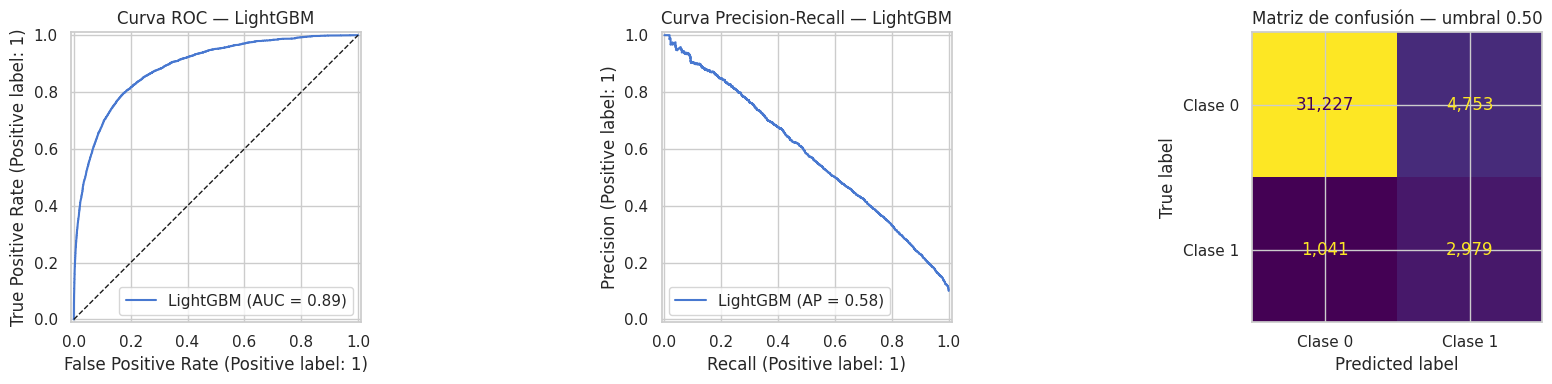

In [17]:
"""
Sección 8.2 — Modelo principal: LightGBM
=======================================

Qué hace esta celda:
- Entrena un modelo LightGBM sobre las 400 variables predictoras.
- Ajusta el desbalance de clases mediante scale_pos_weight.
- Evalúa el modelo en validación usando la función común.
- Verifica que las probabilidades predichas están en un rango razonable.

Por qué LightGBM:
  Es un modelo basado en árboles capaz de capturar relaciones no lineales
  e interacciones entre variables. Además, funciona bien con datos tabulares
  y no requiere estandarización.

Por qué scale_pos_weight:
  El target tiene un desbalance aproximado de 9:1. Este parámetro aumenta
  el peso relativo de la clase positiva durante el entrenamiento.
"""

import lightgbm as lgb


# ------------------------------------------------------------
# Cálculo del peso de la clase positiva
# ------------------------------------------------------------

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("=" * 60)
print("CONFIGURACIÓN LIGHTGBM")
print("=" * 60)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


# ------------------------------------------------------------
# Definición del modelo
# ------------------------------------------------------------

lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)


# ------------------------------------------------------------
# Entrenamiento
# ------------------------------------------------------------

print("\nEntrenando LightGBM...")

lgbm.fit(X_train, y_train)


# ------------------------------------------------------------
# Predicción en validación
# ------------------------------------------------------------

proba_lgbm = lgbm.predict_proba(X_val)[:, 1]


# ------------------------------------------------------------
# Validación rápida de probabilidades
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VALIDACIÓN DE PROBABILIDADES")
print("=" * 60)
print(f"Probabilidad mínima : {proba_lgbm.min():.4f}")
print(f"Probabilidad máxima : {proba_lgbm.max():.4f}")
print(f"Probabilidad media  : {proba_lgbm.mean():.4f}")

assert proba_lgbm.min() >= 0, "Hay probabilidades menores que 0"
assert proba_lgbm.max() <= 1, "Hay probabilidades mayores que 1"


# ------------------------------------------------------------
# Evaluación
# ------------------------------------------------------------

res_lgbm = eval_modelo(
    nombre="LightGBM",
    y_true=y_val,
    proba=proba_lgbm,
    th=0.5
)

## Conclusión del modelo LightGBM

LightGBM obtiene un **ROC-AUC de 0.8885**, superando claramente al baseline de Regresión Logística, que obtuvo un ROC-AUC de 0.8626.

La mejora también se observa en **Average Precision**, que pasa de 0.5072 a 0.5825. Esta métrica es especialmente relevante en este problema porque la clase positiva representa aproximadamente el 10% del dataset.

Con el umbral por defecto de `0.50`, LightGBM consigue:

- **precision:** 0.3853
- **recall:** 0.7410
- **F1-score:** 0.5070

Frente al baseline, LightGBM mejora la precision y el F1-score, aunque reduce ligeramente el recall. Esto indica que el modelo principal identifica menos positivos totales, pero con mayor calidad.

Desde una perspectiva de negocio, este comportamiento puede ser preferible si el banco quiere reducir falsos positivos y evitar acciones comerciales innecesarias, manteniendo al mismo tiempo una capacidad alta para detectar clientes con probabilidad de transaccionar.

La validación de probabilidades muestra un rango amplio, desde 0.0006 hasta 0.9892, por lo que el modelo no presenta colapso en las predicciones. Esto confirma que LightGBM está discriminando correctamente entre clientes con baja y alta probabilidad estimada.

## 8.3 Comparativa de modelos

Una vez entrenados el baseline de Regresión Logística y el modelo principal LightGBM, se comparan sus resultados sobre la misma partición de validación.

La comparación permite evaluar si el aumento de complejidad del modelo está justificado por una mejora real en rendimiento.

Se analizan métricas independientes del umbral, como `ROC-AUC` y `Average Precision`, junto con métricas dependientes del umbral `0.50`, como `precision`, `recall` y `F1-score`.

In [18]:
"""
Sección 8.3 — Comparativa de modelos
====================================

Qué hace esta celda:
- Construye una tabla comparativa de los modelos entrenados.
- Compara métricas independientes del umbral: ROC-AUC y Average Precision.
- Compara métricas dependientes del umbral: precision, recall y F1-score.
- Calcula la mejora de LightGBM frente al baseline.

Por qué es importante:
  Un modelo más complejo solo se justifica si aporta una mejora real
  frente a un baseline más simple.
"""

# ------------------------------------------------------------
# Construcción de tabla comparativa
# ------------------------------------------------------------

resultados = pd.DataFrame([res_lr, res_lgbm])

# Ordenamos columnas principales
columnas_comparacion = [
    "modelo",
    "roc_auc",
    "average_precision",
    "precision",
    "recall",
    "f1",
    "threshold"
]

resultados = resultados[columnas_comparacion].copy()

# ------------------------------------------------------------
# Cálculo de mejoras frente al baseline
# ------------------------------------------------------------

baseline_roc = resultados.loc[0, "roc_auc"]
baseline_ap = resultados.loc[0, "average_precision"]
baseline_f1 = resultados.loc[0, "f1"]

resultados["mejora_roc_auc"] = resultados["roc_auc"] - baseline_roc
resultados["mejora_average_precision"] = resultados["average_precision"] - baseline_ap
resultados["mejora_f1"] = resultados["f1"] - baseline_f1

# Redondeo para lectura
resultados = resultados.round(4)


# ------------------------------------------------------------
# Visualización de tabla
# ------------------------------------------------------------

print("=" * 80)
print("COMPARATIVA DE MODELOS — VALIDACIÓN")
print("=" * 80)

display(resultados)

COMPARATIVA DE MODELOS — VALIDACIÓN


,modelo,roc_auc,average_precision,precision,recall,f1,threshold,mejora_roc_auc,mejora_average_precision,mejora_f1
0,Regresión Logística baseline,0.8626,0.5072,0.2911,0.7754,0.4233,0.5,0.0000,0.0000,0.0000
1,LightGBM,0.8885,0.5825,0.3853,0.7410,0.5070,0.5,0.0258,0.0753,0.0837


## Conclusión de la comparativa de modelos

La comparativa confirma que LightGBM supera al baseline de Regresión Logística en las métricas principales.

La mejora en **ROC-AUC** es de **+0.0258**, pasando de 0.8626 a 0.8885. Esto indica que LightGBM ordena mejor a los clientes según su probabilidad estimada de transacción.

La mejora en **Average Precision** es de **+0.0753**, especialmente relevante en este problema debido al desbalance de clases.

También mejora el **F1-score** en **+0.0837**, lo que muestra un mejor equilibrio entre precision y recall con el umbral por defecto de `0.50`.

Aunque LightGBM reduce ligeramente el recall frente a la Regresión Logística, mejora de forma clara la precision. Desde una perspectiva de negocio, esto implica menos falsos positivos y, por tanto, menor desperdicio de recursos comerciales.

Por estos motivos, LightGBM se selecciona como modelo principal para las siguientes etapas de evaluación, análisis de umbral y generación de la submission final.

# 9. Evaluación e interpretabilidad

Con el modelo LightGBM entrenado, se profundiza en tres aspectos:

1. **Importancia de variables:** qué variables han tenido mayor peso en las decisiones del modelo.
2. **Análisis del umbral óptimo:** el umbral `0.50` no tiene por qué ser el mejor en un problema con clases desbalanceadas. Se analizará qué umbral maximiza el F1-score.
3. **Interpretación de negocio:** traducción de los resultados técnicos a implicaciones comprensibles para stakeholders no técnicos.

Es importante aclarar que la interpretabilidad en este dataset está limitada por la anonimización de las variables. No podemos explicar qué significa una variable desde el punto de vista financiero, pero sí podemos analizar qué variables aportan más señal predictiva al modelo.

## 9.1 Importancia de variables en LightGBM

En esta sección se analiza la importancia de variables del modelo LightGBM.

El objetivo principal es comprobar si las variables generadas mediante Frequency Encoding aparecen entre las más relevantes del modelo. Si esto ocurre, sería una evidencia de que el Feature Engineering aportó información útil más allá de las variables originales.

La importancia se analizará usando dos criterios:

- **Gain:** mide cuánto contribuye una variable a mejorar la función objetivo del modelo.
- **Split:** mide cuántas veces una variable se utiliza para dividir nodos en los árboles.

Para ordenar las variables se utilizará `gain`, ya que suele ser más informativo que el simple número de splits.

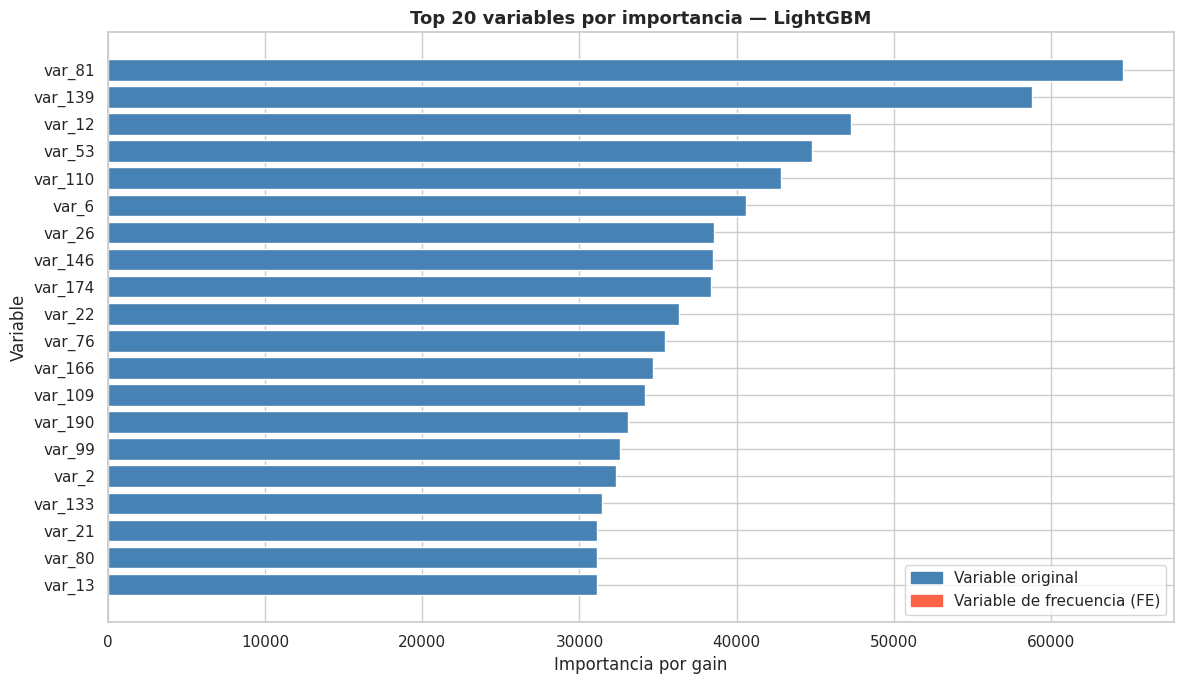

IMPORTANCIA DE VARIABLES — RESUMEN
Variables originales en top 20   : 20/20
Variables de frecuencia en top 20: 0/20

Top 20 variables por gain:


,feature,tipo,importance_gain,importance_split
0,var_81,Original,64616.560421,116
1,var_139,Original,58830.275360,133
2,var_12,Original,47289.385868,135
3,var_53,Original,44797.237217,166
4,var_110,Original,42846.266460,134
5,var_6,Original,40583.611053,143
6,var_26,Original,38574.392284,123
7,var_146,Original,38519.711365,143
8,var_174,Original,38365.158184,158
9,var_22,Original,36349.123444,143


In [19]:
"""
Sección 9.1 — Importancia de variables en LightGBM
=================================================

Qué hace esta celda:
- Extrae la importancia de variables del modelo LightGBM.
- Calcula importancia por gain y por split.
- Visualiza las 20 variables más importantes según gain.
- Distingue entre variables originales y variables de frecuencia.

Por qué importa este análisis:
  Si las variables de frecuencia aparecen entre las más importantes,
  es una señal de que el Frequency Encoding aportó valor predictivo al modelo.

Limitación:
  La importancia de variables no implica causalidad.
  En este dataset, las variables están anonimizadas, por lo que solo podemos
  hablar de señal predictiva, no de explicación de negocio directa.
"""

from matplotlib.patches import Patch


# ------------------------------------------------------------
# Extracción de importancias del modelo
# ------------------------------------------------------------

importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importance_gain": lgbm.booster_.feature_importance(importance_type="gain"),
    "importance_split": lgbm.booster_.feature_importance(importance_type="split")
})

importancias["tipo"] = importancias["feature"].apply(
    lambda x: "Frecuencia (FE)" if x.endswith("_freq") else "Original"
)

importancias_top20 = (
    importancias
    .sort_values("importance_gain", ascending=False)
    .head(20)
    .copy()
)


# ------------------------------------------------------------
# Colores según tipo de variable
# ------------------------------------------------------------

colores = importancias_top20["tipo"].map({
    "Frecuencia (FE)": "tomato",
    "Original": "steelblue"
})


# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.barh(
    importancias_top20["feature"],
    importancias_top20["importance_gain"],
    color=colores,
    edgecolor="white"
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 variables por importancia — LightGBM",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Importancia por gain")
plt.ylabel("Variable")

leyenda = [
    Patch(color="steelblue", label="Variable original"),
    Patch(color="tomato", label="Variable de frecuencia (FE)")
]

plt.legend(handles=leyenda, loc="lower right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Resumen numérico
# ------------------------------------------------------------

n_freq_top20 = (importancias_top20["tipo"] == "Frecuencia (FE)").sum()
n_original_top20 = (importancias_top20["tipo"] == "Original").sum()

print("=" * 60)
print("IMPORTANCIA DE VARIABLES — RESUMEN")
print("=" * 60)

print(f"Variables originales en top 20   : {n_original_top20}/20")
print(f"Variables de frecuencia en top 20: {n_freq_top20}/20")

print("\nTop 20 variables por gain:")
display(
    importancias_top20[
        ["feature", "tipo", "importance_gain", "importance_split"]
    ].reset_index(drop=True)
)

## Conclusión de la importancia de variables

El análisis de importancia por `gain` muestra que las 20 variables más relevantes para LightGBM son variables originales, no variables de frecuencia.

Esto indica que, según este criterio de importancia, el modelo obtiene su mayor ganancia predictiva a partir de las variables originales del dataset.

Este resultado no implica que las variables de frecuencia no aporten valor, sino que su contribución no aparece entre las principales variables por `gain`. Para medir su impacto real, sería necesario realizar una prueba de ablación comparando:

- LightGBM entrenado solo con las 200 variables originales.
- LightGBM entrenado con las 400 variables predictoras, incluyendo Frequency Encoding.

Dado que las variables están anonimizadas, la importancia de variables debe interpretarse como señal predictiva, no como explicación causal o de negocio.

## 9.2 Análisis del umbral óptimo

El modelo LightGBM genera una puntuación probabilística para cada cliente. Para convertir esa probabilidad en una clase final (`0` o `1`), es necesario definir un umbral de decisión.

El umbral por defecto suele ser `0.50`, pero no tiene por qué ser el más adecuado, especialmente en un problema con clases desbalanceadas y con costes distintos entre falsos positivos y falsos negativos.

En este caso se analizarán distintos umbrales entre `0.05` y `0.95`, calculando para cada uno:

- `precision`
- `recall`
- `F1-score`

El objetivo técnico será identificar el umbral que maximiza el **F1-score**, métrica que busca un equilibrio entre precision y recall.

Desde una perspectiva de negocio, este umbral no debe interpretarse como una decisión automática. Si el banco prioriza no perder oportunidades, podría preferir un umbral con mayor recall. Si prioriza reducir acciones comerciales innecesarias, podría preferir un umbral con mayor precision.

ANÁLISIS DE UMBRAL — LIGHTGBM


,escenario,umbral,precision,recall,f1
0,Umbral 0.50,0.50,0.3853,0.7410,0.5070
1,Máximo F1,0.65,0.5373,0.5547,0.5459


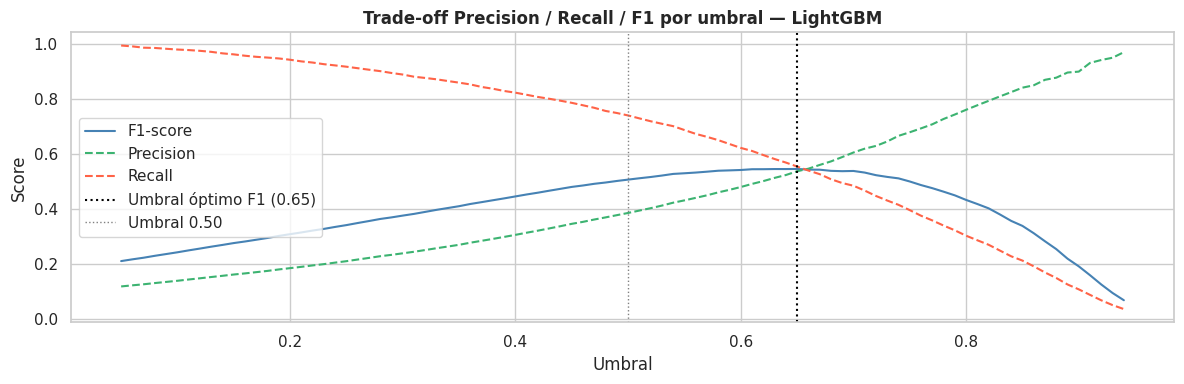

In [20]:
"""
Sección 9.2 — Análisis del umbral óptimo
========================================

Qué hace esta celda:
- Evalúa distintos umbrales de clasificación para LightGBM.
- Calcula precision, recall y F1-score para cada umbral.
- Identifica el umbral que maximiza el F1-score.
- Compara el umbral óptimo frente al umbral por defecto de 0.50.

Por qué es importante:
  ROC-AUC evalúa la capacidad de ranking del modelo, pero no define
  qué clientes serán marcados como positivos. Para tomar una decisión
  operativa, necesitamos elegir un umbral.

Limitación:
  El umbral que maximiza F1 es una decisión técnica. La decisión final
  debería depender del coste de falsos positivos y falsos negativos.
"""

from sklearn.metrics import f1_score, precision_score, recall_score


# ------------------------------------------------------------
# Evaluación de métricas por umbral
# ------------------------------------------------------------

umbrales = np.arange(0.05, 0.95, 0.01)

metricas_umbral = []

for th in umbrales:
    y_pred_th = (proba_lgbm >= th).astype(int)

    metricas_umbral.append({
        "umbral": th,
        "precision": precision_score(y_val, y_pred_th, zero_division=0),
        "recall": recall_score(y_val, y_pred_th, zero_division=0),
        "f1": f1_score(y_val, y_pred_th, zero_division=0)
    })

df_umbrales = pd.DataFrame(metricas_umbral)


# ------------------------------------------------------------
# Identificación del umbral óptimo por F1
# ------------------------------------------------------------

idx_optimo = df_umbrales["f1"].idxmax()

umbral_optimo = df_umbrales.loc[idx_optimo, "umbral"]
precision_optima = df_umbrales.loc[idx_optimo, "precision"]
recall_optimo = df_umbrales.loc[idx_optimo, "recall"]
f1_optimo = df_umbrales.loc[idx_optimo, "f1"]


# ------------------------------------------------------------
# Comparación contra umbral 0.50
# ------------------------------------------------------------

y_pred_05 = (proba_lgbm >= 0.50).astype(int)

precision_05 = precision_score(y_val, y_pred_05, zero_division=0)
recall_05 = recall_score(y_val, y_pred_05, zero_division=0)
f1_05 = f1_score(y_val, y_pred_05, zero_division=0)

comparativa_umbrales = pd.DataFrame([
    {
        "escenario": "Umbral 0.50",
        "umbral": 0.50,
        "precision": precision_05,
        "recall": recall_05,
        "f1": f1_05
    },
    {
        "escenario": "Máximo F1",
        "umbral": umbral_optimo,
        "precision": precision_optima,
        "recall": recall_optimo,
        "f1": f1_optimo
    }
]).round(4)

print("=" * 60)
print("ANÁLISIS DE UMBRAL — LIGHTGBM")
print("=" * 60)

display(comparativa_umbrales)


# ------------------------------------------------------------
# Visualización del trade-off
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["f1"],
    color="steelblue",
    label="F1-score"
)

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["precision"],
    color="mediumseagreen",
    linestyle="--",
    label="Precision"
)

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["recall"],
    color="tomato",
    linestyle="--",
    label="Recall"
)

plt.axvline(
    umbral_optimo,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"Umbral óptimo F1 ({umbral_optimo:.2f})"
)

plt.axvline(
    0.50,
    color="gray",
    linestyle=":",
    linewidth=1,
    label="Umbral 0.50"
)

plt.title(
    "Trade-off Precision / Recall / F1 por umbral — LightGBM",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Umbral")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión del análisis de umbral

El análisis muestra que el umbral por defecto de `0.50` no maximiza el F1-score del modelo LightGBM.

Con `threshold = 0.50`, el modelo prioriza el recall: detecta una mayor proporción de clientes que sí transaccionarán, pero genera más falsos positivos.

El umbral que maximiza el F1-score en validación es `0.65`. Con este umbral, la precision aumenta de **0.3853** a **0.5373**, mientras que el recall disminuye de **0.7410** a **0.5547**. El F1-score mejora de **0.5070** a **0.5459**.

Desde una perspectiva de negocio, esto representa un cambio claro de estrategia:

- Si el banco quiere capturar el mayor número posible de clientes con probabilidad de transaccionar, puede preferir un umbral más bajo.
- Si el banco quiere reducir contactos comerciales innecesarios y priorizar clientes con mayor confianza, el umbral `0.65` resulta más equilibrado.

Para la submission de Kaggle, este umbral no se aplica directamente, ya que Kaggle evalúa probabilidades mediante ROC-AUC. El análisis de umbral sirve para interpretar cómo podría utilizarse el modelo en un escenario operativo real.

COMPARACIÓN OPERATIVA DE UMBRALES — LIGHTGBM


,escenario,umbral,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
0,Umbral 0.50,0.50,0.3853,0.7410,0.5070,31227,4753,1041,2979
1,Umbral óptimo F1 (0.65),0.65,0.5373,0.5547,0.5459,34060,1920,1790,2230


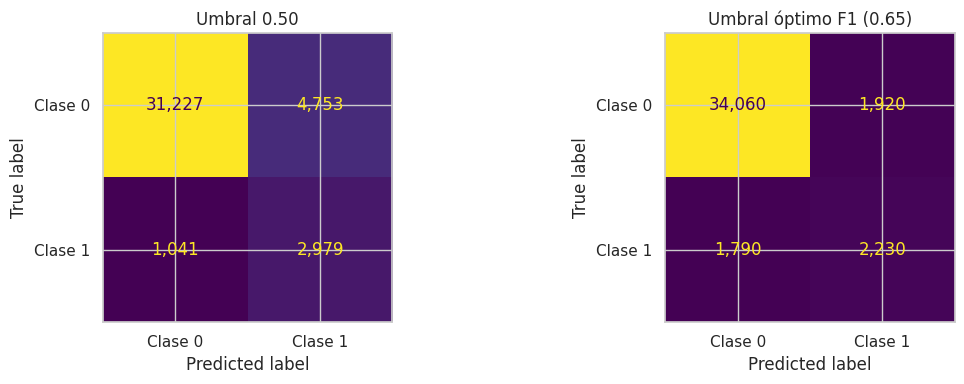

IMPACTO DEL CAMBIO DE UMBRAL
Reducción de falsos positivos : 2,833
Aumento de falsos negativos   : 749


In [21]:
"""
Sección 9.2B — Comparación operativa de umbrales
================================================

Qué hace esta celda:
- Compara el umbral por defecto 0.50 frente al umbral óptimo por F1.
- Calcula métricas y matriz de confusión para ambos escenarios.
- Traduce el cambio de umbral a impacto operativo: falsos positivos y falsos negativos.

Por qué no repetimos ROC y PR:
  Las curvas ROC y Precision-Recall dependen de las probabilidades del modelo,
  no de un umbral concreto. Al cambiar el umbral, cambian las clases predichas
  y la matriz de confusión, pero no las curvas globales.
"""

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# ------------------------------------------------------------
# Función auxiliar para resumir umbrales
# ------------------------------------------------------------

def resumen_umbral(nombre, threshold, y_true, proba):
    """
    Calcula métricas operativas para un umbral concreto.
    """

    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "escenario": nombre,
        "umbral": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }


# ------------------------------------------------------------
# Comparación de escenarios
# ------------------------------------------------------------

resumen_05 = resumen_umbral(
    nombre="Umbral 0.50",
    threshold=0.50,
    y_true=y_val,
    proba=proba_lgbm
)

resumen_opt = resumen_umbral(
    nombre=f"Umbral óptimo F1 ({umbral_optimo:.2f})",
    threshold=umbral_optimo,
    y_true=y_val,
    proba=proba_lgbm
)

comparativa_operativa = pd.DataFrame([resumen_05, resumen_opt]).round(4)

print("=" * 80)
print("COMPARACIÓN OPERATIVA DE UMBRALES — LIGHTGBM")
print("=" * 80)

display(comparativa_operativa)


# ------------------------------------------------------------
# Matrices de confusión lado a lado
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, resumen in zip(axes, [resumen_05, resumen_opt]):
    y_pred = (proba_lgbm >= resumen["umbral"]).astype(int)
    cm = confusion_matrix(y_val, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Clase 0", "Clase 1"]
    ).plot(
        ax=ax,
        values_format=",d",
        colorbar=False
    )

    ax.set_title(f"{resumen['escenario']}")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Impacto del cambio de umbral
# ------------------------------------------------------------

reduccion_fp = resumen_05["false_positives"] - resumen_opt["false_positives"]
aumento_fn = resumen_opt["false_negatives"] - resumen_05["false_negatives"]

print("=" * 80)
print("IMPACTO DEL CAMBIO DE UMBRAL")
print("=" * 80)

print(f"Reducción de falsos positivos : {reduccion_fp:,}")
print(f"Aumento de falsos negativos   : {aumento_fn:,}")

## Conclusión de la comparación operativa de umbrales

La comparación entre el umbral por defecto (`0.50`) y el umbral óptimo por F1 (`0.65`) muestra un cambio claro en el comportamiento operativo del modelo.

Con el umbral `0.50`, LightGBM prioriza el recall: identifica **2.979 clientes positivos reales**, pero genera **4.753 falsos positivos**. Este enfoque puede ser adecuado si el banco quiere minimizar la pérdida de oportunidades y el coste de contactar clientes es bajo.

Con el umbral `0.65`, el modelo se vuelve más selectivo. Los falsos positivos se reducen de **4.753 a 1.920**, es decir, **2.833 contactos comerciales innecesarios menos** en el conjunto de validación. A cambio, los falsos negativos aumentan de **1.041 a 1.790**, por lo que se dejan escapar **749 clientes positivos adicionales**.

Desde una perspectiva de negocio, el umbral `0.65` ofrece un equilibrio más eficiente entre precision y recall, maximizando el F1-score. Sin embargo, la elección final del umbral dependería del coste relativo entre contactar clientes que no transaccionarán y perder clientes que sí lo harían.

Para la submission de Kaggle no se aplicará ningún umbral, ya que la competición evalúa probabilidades mediante ROC-AUC. Este análisis sirve para interpretar cómo podría utilizarse el modelo en un escenario operativo real.

## 9.3 Interpretación de resultados en clave de negocio

El modelo LightGBM obtiene un **ROC-AUC de 0.8885** en el conjunto de validación, superando al baseline de Regresión Logística y mostrando una capacidad discriminativa alta para ordenar clientes según su probabilidad estimada de transacción.

Desde una perspectiva operativa, se analizaron dos configuraciones de umbral con objetivos distintos:

### Umbral 0.50 — enfoque orientado a recall

Con el umbral por defecto de `0.50`, el modelo identifica correctamente el **74.10%** de los clientes que sí transaccionarán, con una precision del **38.53%**.

Este enfoque puede ser adecuado cuando el coste de perder una oportunidad de negocio es alto y el banco prefiere contactar a más clientes aunque aumente el número de falsos positivos.

### Umbral 0.65 — enfoque orientado a equilibrio precision/recall

El umbral que maximiza el F1-score en validación es `0.65`.

Con este umbral, la precision aumenta hasta **53.73%** y el recall se sitúa en **55.47%**. Esto significa que el modelo se vuelve más selectivo: reduce contactos comerciales innecesarios, aunque deja fuera a más clientes que sí habrían transaccionado.

Este enfoque puede ser más adecuado cuando los recursos comerciales son limitados o cuando se prioriza la calidad de las alertas sobre la cantidad de clientes contactados.

### Lectura final de negocio

En ambos escenarios, el modelo aporta valor frente a una estrategia sin priorización, ya que permite ordenar a los clientes según su probabilidad estimada de transacción.

Esto permitiría al equipo comercial concentrar sus esfuerzos en los clientes con mayor propensión, optimizando recursos y adaptando el umbral de decisión al objetivo de negocio:

- mayor cobertura de oportunidades mediante un umbral más bajo;
- mayor eficiencia comercial mediante un umbral más alto.

Para la competición Kaggle, se utilizarán las probabilidades predichas por el modelo sin aplicar umbral, ya que la métrica oficial es ROC-AUC.

# 10. Submission a Kaggle

Con el modelo LightGBM entrenado y evaluado, el último paso es generar predicciones sobre el test oficial de Kaggle y construir el archivo de submission.

La competición evalúa mediante **ROC-AUC**, por lo que se deben enviar **probabilidades continuas** para la clase positiva (`target = 1`), no etiquetas binarias.

Por tanto, no se aplicará ningún umbral de clasificación en esta fase. El análisis de umbrales realizado anteriormente sirve para interpretar el posible uso operativo del modelo, pero no para generar la submission de Kaggle.

El archivo final debe contener dos columnas:

| Columna | Descripción |
|---|---|
| `ID_code` | Identificador del cliente en el test |
| `target` | Probabilidad predicha de que el cliente pertenezca a la clase positiva |

La submission debe contener exactamente las mismas filas que `test.csv`: **200.000 observaciones**.

In [22]:
"""
Sección 10 — Generación de submission a Kaggle
==============================================

Qué hace esta celda:
- Genera probabilidades sobre el test oficial completo de Kaggle.
- Construye el archivo de submission en el formato requerido.
- Valida dimensiones, columnas, IDs y rango de probabilidades.
- Guarda el archivo CSV en la carpeta de salida.

Por qué usamos probabilidades y no clases:
  La métrica oficial de Kaggle es ROC-AUC. Esta métrica evalúa la capacidad
  del modelo para ordenar correctamente los casos positivos por encima de
  los negativos a través de todos los umbrales posibles.

  Por eso, la submission debe contener probabilidades continuas, no etiquetas
  binarias 0/1.
"""

# ------------------------------------------------------------
# Validaciones previas
# ------------------------------------------------------------

assert "lgbm" in globals(), "El modelo LightGBM no existe. Ejecuta primero la sección 8.2"
assert "X_test" in globals(), "X_test no existe. Ejecuta primero la sección 7.1"
assert X_test.shape[0] == test.shape[0], "X_test no tiene el mismo número de filas que test"
assert X_test.shape[1] == 400, f"X_test debería tener 400 features, pero tiene {X_test.shape[1]}"

# ------------------------------------------------------------
# Predicciones sobre el test completo de Kaggle
# ------------------------------------------------------------

proba_kaggle = lgbm.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Construcción del DataFrame de submission
# ------------------------------------------------------------

submission = pd.DataFrame({
    "ID_code": test["ID_code"].values,
    "target": proba_kaggle
})

# ------------------------------------------------------------
# Validación de formato
# ------------------------------------------------------------

print("=" * 60)
print("VALIDACIÓN DE SUBMISSION")
print("=" * 60)

print(f"Dimensiones submission : {submission.shape}")
print(f"Columnas submission    : {submission.columns.tolist()}")

assert submission.shape == (200_000, 2), (
    f"La submission debería tener shape (200000, 2), pero tiene {submission.shape}"
)

assert submission.columns.tolist() == ["ID_code", "target"], (
    "Las columnas de la submission deben ser ['ID_code', 'target']"
)

assert submission["ID_code"].equals(test["ID_code"]), (
    "Los ID_code de la submission no coinciden con los del test original"
)

assert submission["target"].between(0, 1).all(), (
    "Hay probabilidades fuera del rango [0, 1]"
)

assert submission["target"].isna().sum() == 0, (
    "Hay valores nulos en las predicciones"
)

print("\nPrimeras filas:")
display(submission.head(10))

print("\nEstadísticos de las probabilidades predichas:")
print(f"Min   : {submission['target'].min():.4f}")
print(f"Media : {submission['target'].mean():.4f}")
print(f"Max   : {submission['target'].max():.4f}")

# ------------------------------------------------------------
# Guardado del archivo
# ------------------------------------------------------------

SUBMISSION_PATH = OUTPUT_DIR / "submission_lgbm.csv"

submission.to_csv(SUBMISSION_PATH, index=False)

print("\n✅ Submission generada correctamente")
print(f"Archivo guardado en: {SUBMISSION_PATH}")

VALIDACIÓN DE SUBMISSION
Dimensiones submission : (200000, 2)
Columnas submission    : ['ID_code', 'target']

Primeras filas:


,ID_code,target
0,test_0,0.496806
1,test_1,0.658759
2,test_2,0.761775
3,test_3,0.529812
4,test_4,0.217562
5,test_5,0.009442
6,test_6,0.045399
7,test_7,0.451264
8,test_8,0.017584
9,test_9,0.043814



Estadísticos de las probabilidades predichas:
Min   : 0.0003
Media : 0.2981
Max   : 0.9913

✅ Submission generada correctamente
Archivo guardado en: /kaggle/working/submission_lgbm.csv


## Conclusión de la submission

La submission se ha generado correctamente con el formato requerido por Kaggle:

- **200.000 filas**, una por cada cliente del conjunto de test.
- Dos columnas: `ID_code` y `target`.
- Predicciones expresadas como probabilidades continuas entre 0 y 1.
- Sin aplicación de umbral de clasificación.

El archivo final se ha guardado en:

`/kaggle/working/submission_lgbm.csv`

Dado que la métrica oficial de la competición es **ROC-AUC**, se envían probabilidades y no clases binarias. El análisis de umbral realizado anteriormente queda reservado para una posible interpretación operativa del modelo en un contexto de negocio.

# 11. Conclusiones y siguientes pasos

## 11.1 Conclusiones generales

En este proyecto se ha construido un modelo de clasificación binaria para predecir si un cliente realizará una transacción específica en el futuro, utilizando el dataset de la competición **Santander Customer Transaction Prediction** de Kaggle.

El trabajo se ha desarrollado siguiendo un flujo completo de Machine Learning:

1. comprensión del problema y definición del ML Canvas;
2. carga y auditoría técnica del dataset;
3. análisis exploratorio;
4. detección de filas sintéticas en el conjunto de test;
5. construcción de variables mediante Frequency Encoding;
6. entrenamiento de modelos;
7. evaluación técnica y operativa;
8. generación de la submission final para Kaggle.

El modelo principal seleccionado ha sido **LightGBM**, entrenado sobre 400 variables predictoras:

- 200 variables originales anonimizadas;
- 200 variables de frecuencia generadas mediante Frequency Encoding.

En validación, LightGBM obtuvo un **ROC-AUC de 0.8885**, superando al baseline de Regresión Logística, que obtuvo un **ROC-AUC de 0.8626**.

También mejoró otras métricas relevantes:

| Métrica | Regresión Logística | LightGBM |
|---|---:|---:|
| ROC-AUC | 0.8626 | 0.8885 |
| Average Precision | 0.5072 | 0.5825 |
| Precision | 0.2911 | 0.3853 |
| Recall | 0.7754 | 0.7410 |
| F1-score | 0.4233 | 0.5070 |

Estos resultados justifican el uso de LightGBM como modelo principal, ya que mejora la capacidad de ranking y ofrece un mejor equilibrio entre precision y recall frente al baseline.

---

## 11.2 Lectura de negocio

Desde una perspectiva de negocio, el modelo no debe entenderse como una herramienta que toma decisiones automáticamente, sino como un sistema de priorización.

Su utilidad principal es ordenar clientes según su probabilidad estimada de realizar una transacción futura, permitiendo al equipo comercial concentrar recursos en aquellos clientes con mayor propensión.

El análisis de umbrales muestra que el modelo puede adaptarse a distintos objetivos:

- Con un umbral de `0.50`, el modelo prioriza mayor cobertura de clientes positivos, alcanzando un recall de **0.7410**.
- Con un umbral de `0.65`, el modelo mejora la precision hasta **0.5373** y maximiza el F1-score en validación.

La elección final del umbral dependería del coste relativo entre:

- contactar a clientes que no transaccionarán;
- no contactar a clientes que sí habrían transaccionado.

Para la competición Kaggle, no se aplica ningún umbral en la submission, ya que la métrica oficial es ROC-AUC y se evalúan probabilidades continuas.

---

## 11.3 Decisiones técnicas clave

Las decisiones más relevantes del proyecto han sido:

### 1. Uso de ROC-AUC como métrica principal

ROC-AUC es la métrica oficial de la competición y permite evaluar la capacidad del modelo para ordenar correctamente clientes positivos por encima de negativos sin depender de un umbral fijo.

Dado el desbalance de clases, también se analizaron métricas complementarias como Average Precision, precision, recall y F1-score.

### 2. Detección de filas sintéticas en test

El EDA permitió detectar que el conjunto de test se divide en:

- 100.000 filas reales;
- 100.000 filas sintéticas.

Este hallazgo fue clave para construir variables de frecuencia de forma más limpia.

### 3. Frequency Encoding

Se generaron 200 variables adicionales, calculando la frecuencia de aparición de cada valor en `test_real`.

Esta técnica pertenece al contexto específico de Kaggle y debe interpretarse como Feature Engineering transductivo. En un entorno real, su uso requeriría validación adicional para evitar leakage o dependencias no reproducibles.

### 4. Comparación incremental de modelos

El proyecto no empezó directamente con el modelo más complejo. Primero se entrenó una Regresión Logística como baseline y después se comparó contra LightGBM.

Esta estrategia permitió comprobar que el aumento de complejidad estaba justificado por una mejora real en validación.

### 5. Análisis de umbral

Aunque Kaggle evalúa probabilidades mediante ROC-AUC, se analizó el impacto operativo de distintos umbrales para traducir el modelo a una posible decisión de negocio.

---

## 11.4 Limitaciones del proyecto

Este proyecto tiene varias limitaciones importantes:

1. **Variables completamente anonimizadas**  
   No es posible interpretar las variables desde una perspectiva financiera real. La importancia de variables solo indica señal predictiva, no causalidad ni explicación de negocio directa.

2. **Validación basada en un único split**  
   El rendimiento se ha evaluado con una partición train/validation estratificada. Aunque es suficiente para una primera versión, una evaluación más robusta debería usar Stratified K-Fold Cross Validation.

3. **Uso transductivo del test**  
   El Frequency Encoding utiliza información del conjunto de test sin etiquetas. Esto es válido dentro del contexto Kaggle, pero no se debe trasladar directamente a producción sin una evaluación rigurosa.

4. **Probabilidades no calibradas**  
   El modelo se entrena con `scale_pos_weight`, lo que ayuda a tratar el desbalance, pero puede afectar a la calibración de probabilidades. Para decisiones operativas reales, sería recomendable calibrar el modelo.

5. **Ausencia de coste económico explícito**  
   El análisis de umbral se ha basado en F1-score, pero en un caso real sería mejor optimizar el umbral según una matriz de costes definida por negocio.

---

## 11.5 Siguientes pasos

Para mejorar y profesionalizar el proyecto en futuras iteraciones, los siguientes pasos serían:

1. **Stratified K-Fold Cross Validation**  
   Evaluar la estabilidad del modelo en varias particiones y reducir la dependencia de un único split.

2. **Ablation study del Frequency Encoding**  
   Comparar LightGBM con:
   - solo variables originales;
   - variables originales + Frequency Encoding.

   Esto permitiría medir de forma directa cuánto aporta realmente el Feature Engineering.

3. **Optimización de hiperparámetros**  
   Realizar tuning con Optuna o una búsqueda controlada sobre parámetros como:
   - `num_leaves`;
   - `max_depth`;
   - `min_child_samples`;
   - `subsample`;
   - `colsample_bytree`;
   - `learning_rate`;
   - `n_estimators`.

4. **Calibración de probabilidades**  
   Evaluar técnicas como Platt Scaling o Isotonic Regression para mejorar la interpretación probabilística del modelo en un contexto operativo.

5. **Análisis SHAP**  
   Incorporar interpretabilidad local y global mediante SHAP, siempre aclarando que las variables son anonimizadas y que no se puede inferir causalidad de negocio.

6. **Modelos adicionales y ensemble**  
   Comparar LightGBM con otros modelos de boosting como XGBoost o CatBoost y evaluar si un ensemble mejora el ROC-AUC.

7. **Definición de matriz de costes**  
   En un escenario empresarial real, definir junto al equipo de negocio el coste de falsos positivos y falsos negativos para elegir el umbral de decisión de forma económica, no solo estadística.

---

## 11.6 Cierre final

El proyecto demuestra que un flujo de Machine Learning bien estructurado permite ir más allá de entrenar un modelo y obtener un score.

La parte más relevante no ha sido únicamente el resultado final, sino la construcción de un proceso trazable:

- entender el problema;
- auditar los datos;
- detectar patrones relevantes;
- construir variables justificadas;
- comparar modelos contra un baseline;
- evaluar métricas técnicas y operativas;
- generar una submission reproducible.

LightGBM queda seleccionado como modelo principal por su mejor rendimiento frente al baseline y por su capacidad para capturar relaciones no lineales en datos tabulares anonimizados.

La submission final se ha generado correctamente en el formato requerido por Kaggle, utilizando probabilidades continuas para la clase positiva.